# NYC Yellow Taxi Fleet Deployment & Revenue Optimization
### Notebook 2 — ABT → All Models (Champion & Challengers)

| Section | Model | Role |
|---|---|---|
| 6.0 | Historical zone × day × hour median | Naive baseline (reference) |
| 6.1 | XGBoost Regressor | Initial Champion candidate |
| 6.2 | Support Vector Regression (SVR) | Challenger 1 |
| 6.3 | Multi-Layer Perceptron Neural Network | Challenger 2 |

**Run order.** `ABT.ipynb` → this notebook.

## Business Context
New York City yellow taxi drivers earn only while a passenger is on board, and not every dollar a passenger pays stays with the driver. Each trip carries pass-through charges: the NYS congestion surcharge ($2.50), the MTA tax, the improvement surcharge, the airport fee, and, since **January 5, 2025**, the MTA Congestion Relief Zone fee ($0.75 per yellow-taxi trip in Manhattan's Central Business District). Because these charges are flat per trip, they take a larger share of short, low-fare trips.

How much a driver keeps per occupied hour also depends on **where** and **when** they pick up passengers: some zones and hours produce longer, better-paying trips, while traffic congestion stretches trip time without raising the fare proportionally. A fleet that positions its drivers well can earn more from the same driving hours.

This study uses the NYC Taxi & Limousine Commission (TLC) yellow taxi trip records for **January to November 2025** (3,946,695 trips after the 2025 filter), prepared as an Analytical Base Table (ABT) in `ABT.ipynb`.

## Business Problem / Question
**Problem.** The fleet needs to know which pickup zones, days and hours to prioritize for driver deployment to maximize **net revenue per occupied driving hour** under the post-2025 congestion fees, and how congestion fees, trip length, fare level and traffic conditions affect that revenue efficiency.

**Business question.** *Where and when should the fleet deploy its drivers so that each occupied hour earns the most net revenue after congestion and regulatory fees, and under what fee and traffic conditions should a zone be deprioritized?*

**Output.** A predictive decision-support model that estimates expected net revenue per occupied driving hour for each pickup zone × day × hour combination. The predictions are ranked to produce deployment priorities and interpreted to identify the congestion, fare and trip-length conditions associated with lower revenue efficiency.

- **Unit of analysis:** Pickup Zone × Date × Pickup Hour, aggregated from individual trips.
- **Target:** `net_revenue_per_hour` = total net revenue ÷ total occupied minutes × 60 for each zone-hour, where net revenue = `total_amount` − (CBD fee + congestion surcharge + airport fee + MTA tax + improvement surcharge).

## Analytical Questions
1. **AQ1 — Shift scheduling and zone positioning.** Which day-of-week and pickup-hour combinations should the fleet prioritize for driver deployment based on trip demand and revenue generated per occupied driving hour, and how does this vary across pickup zones?
2. **AQ2 — Congestion-fee impact and fare/trip-length thresholds.** To what extent do 2025 congestion fees reduce gross trip revenue across different fare tiers and pickup zones, and what trip-length thresholds or minimum fare should be applied to guide drivers to optimal zone-positioning to reduce revenue loss?
3. **AQ3 — Congestion tipping points.** At what levels of traffic congestion do pickup zones begin to show lower net take per occupied driving hour, and which zones should the fleet deprioritize when congestion becomes too costly?

## Methodology
**Approach:** supervised regression + prescriptive ranking, following the comparative structure of Kankanamge et al. (2019), which compares XGBoost with SVR and a Neural Network on large-scale taxi data.

1. **Data and validation (Sections 1–3).** Load the ABT, confirm its shape, types and 2025 date range, explore the target across hours, days and zones (10% sample), and remove invalid trips: negative fees, non-positive fare/total/net revenue/duration, zero passengers, and rate codes outside 1–6.
2. **Aggregation and features (Section 4).** Aggregate trips to Pickup Zone × Date × Hour and rebuild the target from the summed net revenue and occupied minutes. Build a complete zone × hour grid so lags are exact, then add 1-hour and 24-hour lags of trip count (demand), average speed (traffic) and average fee impact, plus pickup hour, day of week and weekend flag. **Leakage rule:** only information known before the hour is used as a predictor.
3. **Chronological split (Section 5).** Split by timestamp into 70% train (Jan 2 – Aug 23), 15% validation (Aug 23 – Oct 12) and 15% test (Oct 12 – Nov 30), so every zone from the same hour stays in one partition. The test period is used only for final evaluation.
4. **Model-specific preparation (Section 5).** XGBoost uses native categorical features without scaling. SVR and the Neural Network use median imputation, standard scaling and one-hot encoding, all fit on the training data only.
5. **Models (Section 6).**
   - Naive baseline: historical zone × day × hour median.
   - XGBoost: 15 random configurations tuned on validation MAE with early stopping, then refit on train + validation.
   - SVR: RBF kernel on a 25,000-row training subsample, tuned with a randomized search.
   - Neural Network: three MLP architectures tuned on validation MAE with early stopping.
6. **Evaluation and selection (Section 7).** MAE (primary), RMSE and R² on the same held-out test period, with Spearman rank correlation for XGBoost. The model with the lowest test MAE is the final Champion.
7. **Interpretation (Section 6.1.5).** XGBoost gain importance and SHAP contributions show which conditions raise or lower predicted revenue per hour.

# 1. Environment Setup & Libraries

### 1.1 Libraries

In [1]:
%pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import gc
from pathlib import Path

import xgboost as xgb
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from pandas.api.types import CategoricalDtype
from scipy.stats import spearmanr
from sklearn.model_selection import ParameterSampler, RandomizedSearchCV

sns.set_theme(style="whitegrid")


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


### 1.2 Google Drive & ABT Path Configuration

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ABT_PATH = Path(
        '/content/drive/MyDrive/DSS142P/Data/ABT/NYC_Taxi_ABT.csv'
    )
except ImportError:
    local_candidates = [
        Path('NYC_Taxi_ABT.csv'),
        Path('../data/NYC_Taxi_ABT.csv')
    ]
    ABT_PATH = next(
        (path for path in local_candidates if path.exists()),
        local_candidates[0]
    )

print("ABT found:", ABT_PATH.exists())
print("ABT path:", ABT_PATH)
print(f"File size: {ABT_PATH.stat().st_size / 1024**3:.2f} GB")

ABT found: True
ABT path: NYC_Taxi_ABT.csv
File size: 0.90 GB


In [3]:
sample = pd.read_csv(ABT_PATH, nrows=5)

print("Columns:")
print(sample.columns.tolist())

print("\nData types:")
print(sample.dtypes)

display(sample)

Columns:
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee', 'duration_min', 'speed_mph', 'pickup_hour', 'day_of_week', 'is_weekend', 'pickup_year', 'total_fees', 'net_revenue', 'net_revenue_per_hour', 'fee_impact_pct', 'fare_tier', 'trip_length_tier', 'congestion_level']

Data types:
VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count            int64
trip_distance            float64
RatecodeID                 int64
store_and_fwd_flag        object
PULocationID               int64
DOLocationID               int64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax              

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,day_of_week,is_weekend,pickup_year,total_fees,net_revenue,net_revenue_per_hour,fee_impact_pct,fare_tier,trip_length_tier,congestion_level
0,2,2025-01-18 20:53:30,2025-01-18 21:00:47,1,0.97,1,N,238,166,1,...,Saturday,True,2025,1.50,11.82,97.372998,11.261261,Low Fare,Short Trip,Heavy Traffic
1,1,2025-01-25 11:12:51,2025-01-25 11:17:57,1,0.60,1,N,50,48,2,...,Saturday,True,2025,4.75,5.80,68.235294,45.023697,Low Fare,Short Trip,Heavy Traffic
2,1,2025-01-21 15:09:31,2025-01-21 15:19:02,1,0.80,1,N,236,237,1,...,Tuesday,False,2025,4.00,12.65,79.754816,24.024024,Low Fare,Short Trip,Heavy Traffic
3,2,2025-01-11 22:25:45,2025-01-11 22:34:22,2,1.93,1,N,231,68,1,...,Saturday,True,2025,4.75,15.62,108.765957,23.318606,Medium Fare,Medium Trip,Moderate Traffic
4,2,2025-01-04 23:37:07,2025-01-04 23:45:58,1,4.44,1,N,137,88,0,...,Saturday,True,2025,1.50,33.62,223.783784,4.271071,High Fare,Long Trip,Light Traffic


# 2. Exploratory Data Analysis (EDA)

### 2.1 Load Raw ABT & Inspect Target Distribution (`net_revenue_per_hour`)

ABT Shape: (3946695, 33)
Date Range: 2025-01-01 00:00:17 → 2025-11-30 23:59:59


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,day_of_week,is_weekend,pickup_year,total_fees,net_revenue,net_revenue_per_hour,fee_impact_pct,fare_tier,trip_length_tier,congestion_level
0,2,2025-01-18 20:53:30,2025-01-18 21:00:47,1,0.97,1,N,238,166,1,...,Saturday,True,2025,1.50,11.82,97.372998,11.261261,Low Fare,Short Trip,Heavy Traffic
1,1,2025-01-25 11:12:51,2025-01-25 11:17:57,1,0.60,1,N,50,48,2,...,Saturday,True,2025,4.75,5.80,68.235294,45.023697,Low Fare,Short Trip,Heavy Traffic
2,1,2025-01-21 15:09:31,2025-01-21 15:19:02,1,0.80,1,N,236,237,1,...,Tuesday,False,2025,4.00,12.65,79.754816,24.024024,Low Fare,Short Trip,Heavy Traffic
3,2,2025-01-11 22:25:45,2025-01-11 22:34:22,2,1.93,1,N,231,68,1,...,Saturday,True,2025,4.75,15.62,108.765957,23.318606,Medium Fare,Medium Trip,Moderate Traffic
4,2,2025-01-04 23:37:07,2025-01-04 23:45:58,1,4.44,1,N,137,88,0,...,Saturday,True,2025,1.50,33.62,223.783784,4.271071,High Fare,Long Trip,Light Traffic


Net Revenue per Hour Quantiles:
0.010     $28.56
0.050     $54.96
0.250     $71.61
0.500     $85.41
0.750    $105.17
0.900    $133.77
0.950    $158.31
0.990    $223.78
0.999    $223.78
Name: net_revenue_per_hour, dtype: object

99th percentile cap for readable plotting: $223.78


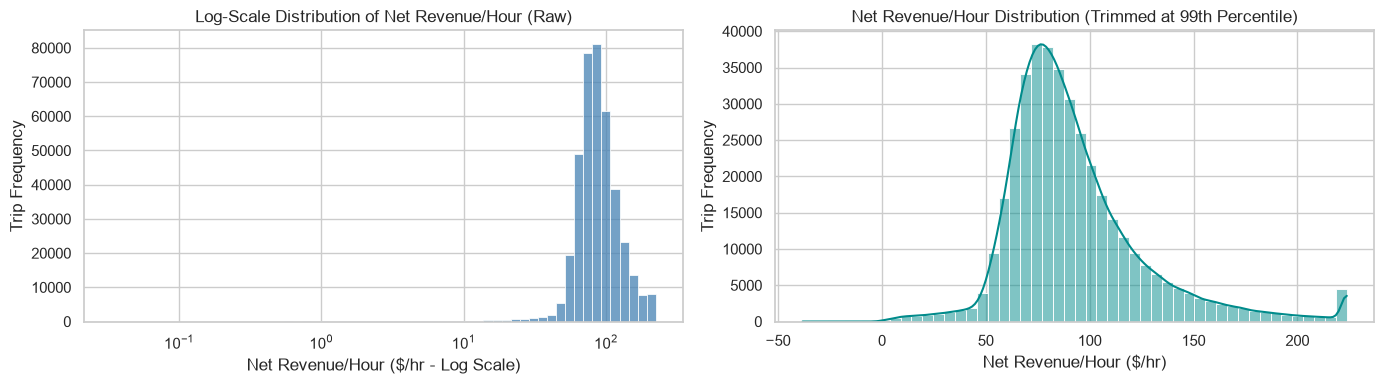

In [4]:
df = pd.read_csv(
    ABT_PATH,
    parse_dates=['tpep_pickup_datetime'],
    low_memory=False
)

print(f"ABT Shape: {df.shape}")
print(
    f"Date Range: "
    f"{df['tpep_pickup_datetime'].min()} → "
    f"{df['tpep_pickup_datetime'].max()}"
)

display(df.head())

# Sample 10% of the dataset for fast, responsive visualization
eda_df = df.sample(frac=0.10, random_state=42).copy()

quantiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
print("Net Revenue per Hour Quantiles:")
print(eda_df['net_revenue_per_hour'].quantile(quantiles).apply(lambda x: f"${x:,.2f}"))

# Identify 99th percentile threshold to cap extreme trip outliers for readable plotting
cap_value = eda_df['net_revenue_per_hour'].quantile(0.99)
print(f"\n99th percentile cap for readable plotting: ${cap_value:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(eda_df['net_revenue_per_hour'], bins=60, log_scale=True, ax=axes[0], color='steelblue')
axes[0].set_title('Log-Scale Distribution of Net Revenue/Hour (Raw)')
axes[0].set_xlabel('Net Revenue/Hour ($/hr - Log Scale)')
axes[0].set_ylabel('Trip Frequency')

sns.histplot(eda_df[eda_df['net_revenue_per_hour'] <= cap_value]['net_revenue_per_hour'],
             bins=50, kde=True, ax=axes[1], color='darkcyan')
axes[1].set_title('Net Revenue/Hour Distribution (Trimmed at 99th Percentile)')
axes[1].set_xlabel('Net Revenue/Hour ($/hr)')
axes[1].set_ylabel('Trip Frequency')

plt.tight_layout()
plt.show()

### 2.2 Temporal Trends (Hourly & Day-of-Week Revenue)

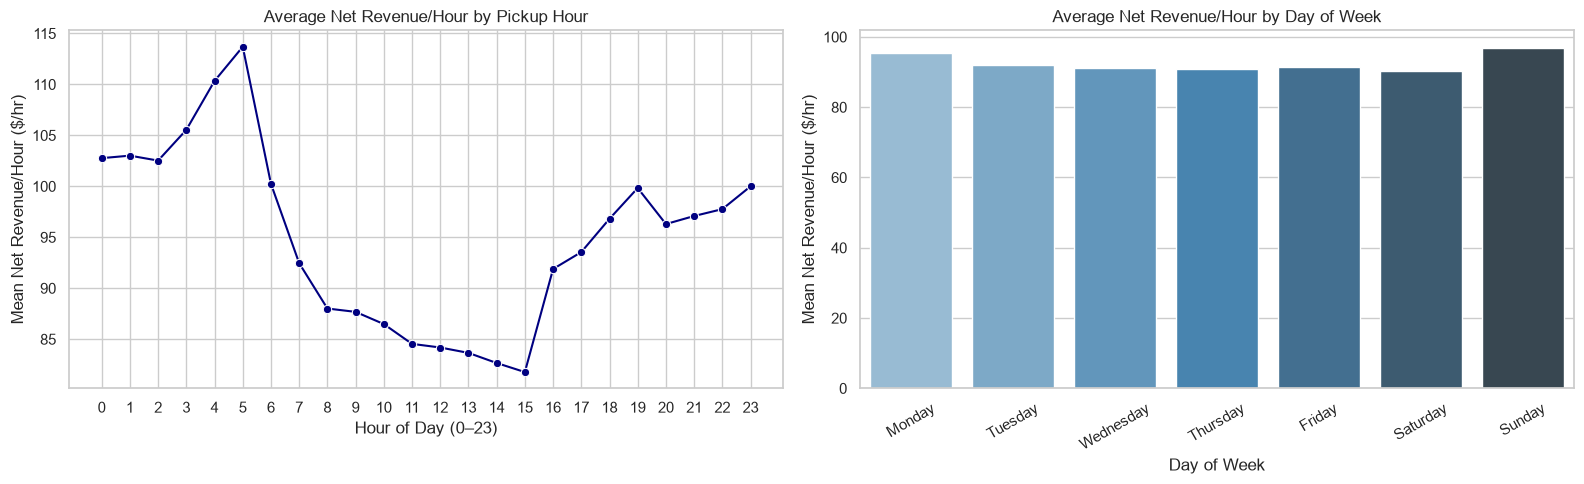

In [5]:
viz_df = eda_df[eda_df['net_revenue_per_hour'] <= cap_value]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hourly_agg = viz_df.groupby('pickup_hour')['net_revenue_per_hour'].mean().reset_index()
sns.lineplot(data=hourly_agg, x='pickup_hour', y='net_revenue_per_hour', marker='o', ax=axes[0], color='navy')
axes[0].set_title('Average Net Revenue/Hour by Pickup Hour')
axes[0].set_xlabel('Hour of Day (0–23)')
axes[0].set_ylabel('Mean Net Revenue/Hour ($/hr)')
axes[0].set_xticks(range(0, 24))

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_agg = viz_df.groupby('day_of_week')['net_revenue_per_hour'].mean().reindex(weekday_order).reset_index()
sns.barplot(
    data=day_agg, x='day_of_week', y='net_revenue_per_hour',
    hue='day_of_week', palette='Blues_d', legend=False, ax=axes[1]
)
axes[1].set_title('Average Net Revenue/Hour by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Mean Net Revenue/Hour ($/hr)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 2.3 Spatial Analysis (Top 10 vs. Bottom 10 Pickup Zones) & Feature Correlations

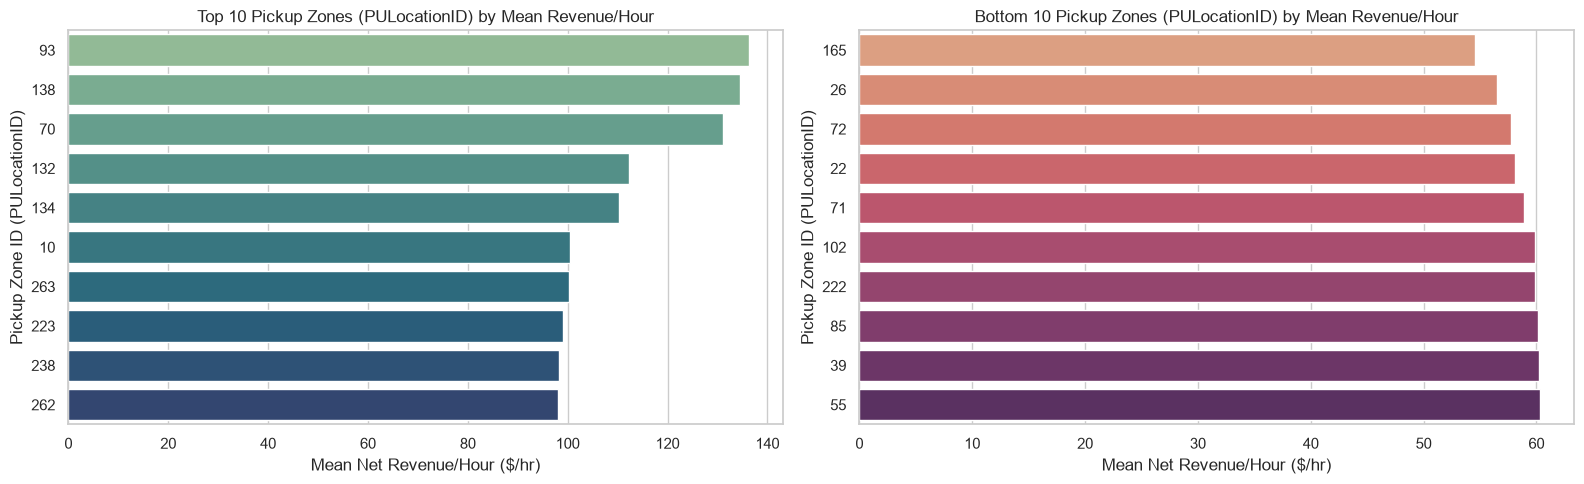

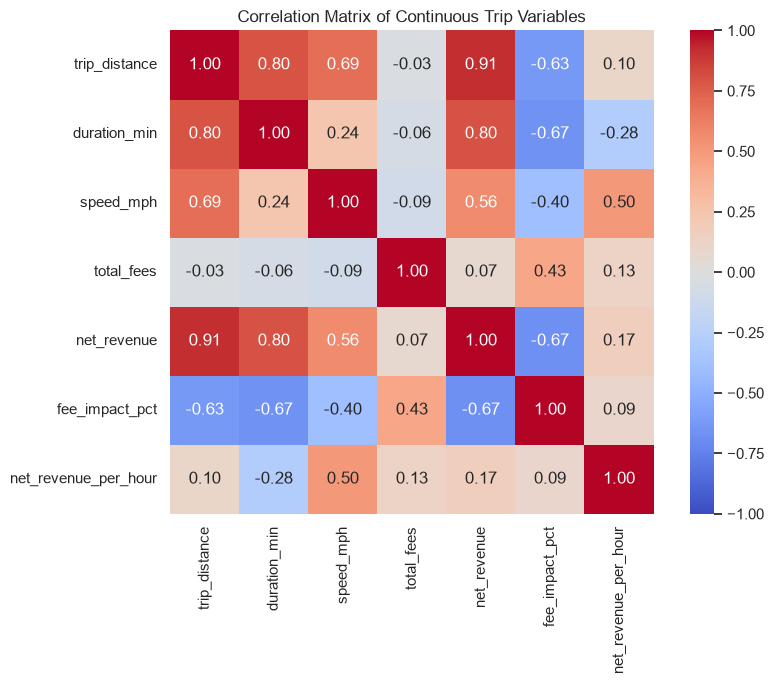

In [6]:
zone_stats = eda_df.groupby('PULocationID').agg(
    mean_revenue=('net_revenue_per_hour', 'mean'),
    trip_count=('net_revenue_per_hour', 'count')
).reset_index()

# Filter for zones with sufficient sample support (>= 50 trips in sample)
zone_stats_filtered = zone_stats[zone_stats['trip_count'] >= 50].copy()
zone_stats_filtered['PULocationID_str'] = zone_stats_filtered['PULocationID'].astype(str)

top_10 = zone_stats_filtered.nlargest(10, 'mean_revenue')
bottom_10 = zone_stats_filtered.nsmallest(10, 'mean_revenue')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=top_10, x='mean_revenue', y='PULocationID_str',
    hue='PULocationID_str', palette='crest', legend=False, ax=axes[0]
)
axes[0].set_title('Top 10 Pickup Zones (PULocationID) by Mean Revenue/Hour')
axes[0].set_xlabel('Mean Net Revenue/Hour ($/hr)')
axes[0].set_ylabel('Pickup Zone ID (PULocationID)')

sns.barplot(
    data=bottom_10, x='mean_revenue', y='PULocationID_str',
    hue='PULocationID_str', palette='flare', legend=False, ax=axes[1]
)
axes[1].set_title('Bottom 10 Pickup Zones (PULocationID) by Mean Revenue/Hour')
axes[1].set_xlabel('Mean Net Revenue/Hour ($/hr)')
axes[1].set_ylabel('Pickup Zone ID (PULocationID)')

plt.tight_layout()
plt.show()

num_cols = [
    'trip_distance', 'duration_min', 'speed_mph',
    'total_fees', 'net_revenue', 'fee_impact_pct',
    'net_revenue_per_hour'
]

corr_matrix = eda_df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix of Continuous Trip Variables')
plt.tight_layout()
plt.show()

# 3. Data Cleaning & Outlier Filtering

In [7]:
initial_rows = len(df)

# 1. Remove negative fees, taxes, and fare adjustments
fee_cols = [
    'cbd_congestion_fee', 'congestion_surcharge', 'Airport_fee',
    'mta_tax', 'extra', 'improvement_surcharge', 'tolls_amount',
    'tip_amount', 'total_fees', 'fee_impact_pct'
]
df = df[(df[fee_cols] >= 0).all(axis=1)].copy()
after_fees = len(df)
print(f"Rows after removing negative fees/taxes: {after_fees:,} (Dropped {initial_rows - after_fees:,})")

# 2. Ensure strictly positive fare, duration, and net revenue amounts
df = df[(df['fare_amount'] > 0) & (df['total_amount'] > 0) & (df['net_revenue'] > 0) & (df['duration_min'] > 0)].copy()
after_revenue = len(df)
print(f"Rows after enforcing positive revenue:   {after_revenue:,} (Dropped {after_fees - after_revenue:,})")

# 3. Remove zero-passenger trips and invalid TLC RatecodeIDs (valid codes are 1 to 6)
df = df[(df['passenger_count'] > 0) & (df['RatecodeID'].between(1, 6))].copy()
after_validity = len(df)
print(f"Rows after removing invalid trips/codes: {after_validity:,} (Dropped {after_revenue - after_validity:,})")

# 4. Filter extreme target outliers (capping net_revenue_per_hour at $500/hr)
df = df[df['net_revenue_per_hour'] <= 500].copy()
final_rows = len(df)
print(f"Rows after capping target outliers:      {final_rows:,} (Dropped {after_validity - final_rows:,})")

print(f"\nTotal rows removed: {initial_rows - final_rows:,} ({((initial_rows - final_rows) / initial_rows) * 100:.2f}%)")

print("\n----- CLEANED DATA VERIFICATION -----")
print(f"Final Row Count:       {len(df):,}")
print(f"Total Missing Values:  {df.isnull().sum().sum()}")
print(f"Min Total Fees:        ${df['total_fees'].min():.2f}")
print(f"Min Fee Impact %:      {df['fee_impact_pct'].min():.2f}%")
print(f"Min Passenger Count:   {df['passenger_count'].min()}")
print(f"Max RatecodeID:        {df['RatecodeID'].max()}")
print(f"Min Speed (mph):       {df['speed_mph'].min():.2f}")
print(f"Max Net Revenue/Hour:  ${df['net_revenue_per_hour'].max():.2f}/hr")

print("\nCleaning complete. Cleaned dataframe retained in memory for Section 4.")

Rows after removing negative fees/taxes: 3,946,629 (Dropped 66)


Rows after enforcing positive revenue:   3,946,629 (Dropped 0)


Rows after removing invalid trips/codes: 3,857,230 (Dropped 89,399)


Rows after capping target outliers:      3,857,230 (Dropped 0)

Total rows removed: 89,465 (2.27%)

----- CLEANED DATA VERIFICATION -----
Final Row Count:       3,857,230


Total Missing Values:  0
Min Total Fees:        $0.00
Min Fee Impact %:      0.00%
Min Passenger Count:   1
Max RatecodeID:        6
Min Speed (mph):       1.00
Max Net Revenue/Hour:  $223.78/hr

Cleaning complete. Cleaned dataframe retained in memory for Section 4.


In [8]:
recomputed_revenue_per_hour = (
    df['net_revenue'] / df['duration_min']
) * 60

target_difference = (
    recomputed_revenue_per_hour
    - df['net_revenue_per_hour']
).abs()

approximately_equal = np.isclose(
    recomputed_revenue_per_hour,
    df['net_revenue_per_hour'],
    rtol=1e-5,
    atol=1e-5
)

print("----- TARGET FORMULA VERIFICATION -----")

print(
    f"Median absolute difference: "
    f"{target_difference.median():.6f}"
)

print(
    f"Mean absolute difference:   "
    f"{target_difference.mean():.6f}"
)

print(
    f"Max absolute difference:    "
    f"{target_difference.max():.6f}"
)

print(
    f"Percent approximately equal: "
    f"{approximately_equal.mean() * 100:.2f}%"
)

----- TARGET FORMULA VERIFICATION -----
Median absolute difference: 0.000000
Mean absolute difference:   1.529667


Max absolute difference:    28744.966216
Percent approximately equal: 98.99%


In [9]:
mismatch_mask = ~approximately_equal

mismatch_df = df.loc[
    mismatch_mask,
    [
        'net_revenue',
        'duration_min',
        'net_revenue_per_hour',
        'PULocationID',
        'tpep_pickup_datetime'
    ]
].copy()

mismatch_df['recomputed_net_revenue_per_hour'] = (
    mismatch_df['net_revenue']
    / mismatch_df['duration_min']
) * 60

mismatch_df['absolute_difference'] = (
    mismatch_df['recomputed_net_revenue_per_hour']
    - mismatch_df['net_revenue_per_hour']
).abs()

print("----- TARGET MISMATCH DIAGNOSTIC -----")
print(f"Mismatched rows: {len(mismatch_df):,}")
print(
    f"Percent of cleaned dataset: "
    f"{len(mismatch_df) / len(df) * 100:.2f}%"
)

print("\nStored target summary:")
print(mismatch_df['net_revenue_per_hour'].describe())

print("\nRecomputed target summary:")
print(mismatch_df['recomputed_net_revenue_per_hour'].describe())

print("\nDuration summary:")
print(mismatch_df['duration_min'].describe())

print("\nLargest mismatches:")
display(
    mismatch_df.sort_values(
        'absolute_difference',
        ascending=False
    ).head(20)
)

----- TARGET MISMATCH DIAGNOSTIC -----
Mismatched rows: 39,117
Percent of cleaned dataset: 1.01%

Stored target summary:
count    3.911700e+04
mean     2.237838e+02
std      5.684415e-14
min      2.237838e+02
25%      2.237838e+02
50%      2.237838e+02
75%      2.237838e+02
max      2.237838e+02
Name: net_revenue_per_hour, dtype: float64

Recomputed target summary:
count    39117.000000
mean       374.620470
std        479.393329
min        223.787089
25%        238.927374
50%        264.613139
75%        323.234043
max      28968.750000
Name: recomputed_net_revenue_per_hour, dtype: float64

Duration summary:
count    39117.000000
mean         7.896070
std          9.262242
min          1.000000
25%          1.850000
50%          3.000000
75%         12.016667
max         86.333333
Name: duration_min, dtype: float64

Largest mismatches:


,net_revenue,duration_min,net_revenue_per_hour,PULocationID,tpep_pickup_datetime,recomputed_net_revenue_per_hour,absolute_difference
2203766,515.00,1.066667,223.783784,80,2025-07-13 21:47:43,28968.750000,28744.966216
3120151,475.00,1.083333,223.783784,197,2025-09-06 19:18:41,26307.692308,26083.908524
714835,274.00,1.116667,223.783784,215,2025-03-19 12:57:38,14722.388060,14498.604276
3224513,390.30,1.950000,223.783784,157,2025-10-05 20:52:19,12009.230769,11785.446985
2437962,480.20,2.616667,223.783784,197,2025-07-20 23:38:19,11010.955414,10787.171630
584574,340.00,1.950000,223.783784,132,2025-02-04 22:00:00,10461.538462,10237.754678
635590,600.00,3.883333,223.783784,226,2025-02-08 21:07:56,9270.386266,9046.602482
2901021,300.00,1.950000,223.783784,226,2025-09-14 19:34:03,9230.769231,9006.985447
1039528,157.29,1.233333,223.783784,124,2025-04-02 13:04:10,7651.945946,7428.162162
1549762,225.00,1.766667,223.783784,132,2025-05-16 08:05:50,7641.509434,7417.725650


**Target Formula Verification.**  
The stored trip-level `net_revenue_per_hour` matched the formula
`(net_revenue / duration_min) × 60` for 98.99% of cleaned observations.

The remaining 1.01% of observations were all stored at approximately
$223.78/hr, while their recomputed values exceeded this level. This indicates
that the trip-level target in the source ABT had been capped at approximately
$223.78/hr.

For zone-hour modeling, `net_revenue_per_hour` was therefore recomputed in
Section 4.1 from aggregated component values as:

`(total_net_revenue / total_occupied_duration_minutes) × 60`

rather than averaging the capped trip-level target. Zone-hour observations were
subsequently restricted to values greater than 0 and no more than $500/hr
according to the modeling outlier rule.

# 4. Spatiotemporal Aggregation & Lag Feature Engineering

### 4.1 Aggregate Trips to Zone-Hour Level (`PULocationID` × `pickup_date`)

In [10]:
print("Aggregating cleaned trips to Pickup Zone × Hour...")

if not pd.api.types.is_datetime64_any_dtype(df['tpep_pickup_datetime']):
    df['tpep_pickup_datetime'] = pd.to_datetime(
        df['tpep_pickup_datetime'],
        errors='coerce'
    )

df['pickup_date'] = df['tpep_pickup_datetime'].dt.floor('h')

grouped = (
    df.groupby(
        ['PULocationID', 'pickup_date'],
        as_index=False
    )
    .agg(
        trip_count=('net_revenue', 'size'),
        total_net_rev=('net_revenue', 'sum'),
        total_duration_min=('duration_min', 'sum'),
        avg_speed_mph=('speed_mph', 'mean'),
        avg_fee_impact_pct=('fee_impact_pct', 'mean')
    )
)

grouped = grouped[
    grouped['total_duration_min'] > 0
].copy()

grouped['net_revenue_per_hour'] = (
    grouped['total_net_rev']
    / grouped['total_duration_min']
) * 60

grouped = grouped[
    (grouped['net_revenue_per_hour'] > 0) &
    (grouped['net_revenue_per_hour'] <= 500)
].copy()

grouped = grouped.sort_values(
    ['pickup_date', 'PULocationID']
).reset_index(drop=True)

print("\n----- ZONE-HOUR AGGREGATION SUMMARY -----")
print(f"Zone-hour observations: {len(grouped):,}")
print(f"Unique pickup zones: {grouped['PULocationID'].nunique():,}")
print(
    f"Time range: {grouped['pickup_date'].min()} "
    f"→ {grouped['pickup_date'].max()}"
)
print(f"Missing values: {grouped.isna().sum().sum():,}")

print("\nTarget summary:")
print(grouped['net_revenue_per_hour'].describe())

display(grouped.head())

Aggregating cleaned trips to Pickup Zone × Hour...



----- ZONE-HOUR AGGREGATION SUMMARY -----
Zone-hour observations: 546,778
Unique pickup zones: 258
Time range: 2025-01-01 00:00:00 → 2025-11-30 23:00:00
Missing values: 0

Target summary:
count    546778.000000
mean         88.189315
std          31.981432
min           0.008280
25%          72.397365
50%          83.752083
75%          97.326606
max         499.304348
Name: net_revenue_per_hour, dtype: float64


,PULocationID,pickup_date,trip_count,total_net_rev,total_duration_min,avg_speed_mph,avg_fee_impact_pct,net_revenue_per_hour
0,12,2025-01-01,1,8.20,5.700000,9.263158,32.786885,86.315789
1,24,2025-01-01,2,43.83,42.900000,11.804847,31.371345,61.300699
2,33,2025-01-01,2,70.26,51.783333,13.294875,4.515664,81.408433
3,41,2025-01-01,4,50.09,59.600000,15.549014,27.876724,50.426174
4,43,2025-01-01,1,11.48,5.283333,12.492114,25.839793,130.372240


In [11]:
del df
gc.collect()

print("Trip-level dataframe released from memory.")
print("Zone-hour dataframe retained as: grouped")

Trip-level dataframe released from memory.
Zone-hour dataframe retained as: grouped


### 4.2 Full Cartesian Time Grid & Autoregressive Lag Features

In [12]:
print("Creating complete Pickup Zone × Hour grid and lag features...")

unique_zones = np.sort(grouped['PULocationID'].unique())

all_hours = pd.date_range(
    start=grouped['pickup_date'].min(),
    end=grouped['pickup_date'].max(),
    freq='h'
)

grid = (
    pd.MultiIndex.from_product(
        [unique_zones, all_hours],
        names=['PULocationID', 'pickup_date']
    )
    .to_frame(index=False)
)

print(f"Complete grid rows: {len(grid):,}")

abt = grid.merge(
    grouped,
    on=['PULocationID', 'pickup_date'],
    how='left'
)

abt = abt.sort_values(
    ['PULocationID', 'pickup_date']
).reset_index(drop=True)

# If a zone has no recorded trip in an hour,
# observed trip demand for that hour is zero.
abt['trip_count'] = abt['trip_count'].fillna(0)

abt['trip_count_lag1h'] = (
    abt.groupby('PULocationID')['trip_count']
    .shift(1)
)

abt['trip_count_lag24h'] = (
    abt.groupby('PULocationID')['trip_count']
    .shift(24)
)

abt['avg_speed_mph_lag1h'] = (
    abt.groupby('PULocationID')['avg_speed_mph']
    .shift(1)
)

abt['avg_speed_mph_lag24h'] = (
    abt.groupby('PULocationID')['avg_speed_mph']
    .shift(24)
)

abt['avg_fee_impact_pct_lag1h'] = (
    abt.groupby('PULocationID')['avg_fee_impact_pct']
    .shift(1)
)

abt['avg_fee_impact_pct_lag24h'] = (
    abt.groupby('PULocationID')['avg_fee_impact_pct']
    .shift(24)
)

abt['pickup_hour'] = abt['pickup_date'].dt.hour

abt['day_of_week'] = (
    abt['pickup_date']
    .dt.day_name()
)

abt['is_weekend'] = (
    abt['pickup_date'].dt.dayofweek >= 5
).astype(int)

modeling_df = abt[
    abt['net_revenue_per_hour'].notna()
].copy()

# Remove the first 24 hours because those observations
# cannot have a genuine previous-day lag yet.
minimum_model_time = (
    abt['pickup_date'].min()
    + pd.Timedelta(hours=24)
)

modeling_df = modeling_df[
    modeling_df['pickup_date'] >= minimum_model_time
].copy()

modeling_df = modeling_df.sort_values(
    ['pickup_date', 'PULocationID']
).reset_index(drop=True)

print("\n----- LAG FEATURE ENGINEERING SUMMARY -----")

print(f"Complete grid rows: {len(abt):,}")
print(f"Rows with observed target: {len(modeling_df):,}")

print(
    f"Modeling time range: "
    f"{modeling_df['pickup_date'].min()} → "
    f"{modeling_df['pickup_date'].max()}"
)

lag_cols = [
    'trip_count_lag1h',
    'trip_count_lag24h',
    'avg_speed_mph_lag1h',
    'avg_speed_mph_lag24h',
    'avg_fee_impact_pct_lag1h',
    'avg_fee_impact_pct_lag24h'
]

print("\nMissing values in lag features:")
print(modeling_df[lag_cols].isna().sum())

display(
    modeling_df[
        [
            'PULocationID',
            'pickup_date',
            'pickup_hour',
            'day_of_week',
            'is_weekend',
            'trip_count',
            'trip_count_lag1h',
            'trip_count_lag24h',
            'avg_speed_mph_lag1h',
            'avg_speed_mph_lag24h',
            'avg_fee_impact_pct_lag1h',
            'avg_fee_impact_pct_lag24h',
            'net_revenue_per_hour'
        ]
    ].head()
)

Creating complete Pickup Zone × Hour grid and lag features...
Complete grid rows: 2,068,128



----- LAG FEATURE ENGINEERING SUMMARY -----
Complete grid rows: 2,068,128
Rows with observed target: 545,385
Modeling time range: 2025-01-02 00:00:00 → 2025-11-30 23:00:00

Missing values in lag features:
trip_count_lag1h                  0
trip_count_lag24h                 0
avg_speed_mph_lag1h          146414
avg_speed_mph_lag24h         150315
avg_fee_impact_pct_lag1h     146414
avg_fee_impact_pct_lag24h    150315
dtype: int64


,PULocationID,pickup_date,pickup_hour,day_of_week,is_weekend,trip_count,trip_count_lag1h,trip_count_lag24h,avg_speed_mph_lag1h,avg_speed_mph_lag24h,avg_fee_impact_pct_lag1h,avg_fee_impact_pct_lag24h,net_revenue_per_hour
0,37,2025-01-02,0,Thursday,0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,6.545455
1,41,2025-01-02,0,Thursday,0,2.0,0.0,4.0,NaN,15.549014,NaN,27.876724,83.116883
2,48,2025-01-02,0,Thursday,0,4.0,4.0,11.0,14.145030,7.687708,13.916702,14.277218,103.393053
3,50,2025-01-02,0,Thursday,0,1.0,1.0,5.0,11.062500,10.653179,29.411765,9.543204,83.452211
4,68,2025-01-02,0,Thursday,0,3.0,4.0,16.0,12.035006,7.986054,20.785748,13.489690,103.074277


# 5. Chronological Data Split & Dual Preprocessing Pipelines

In [13]:
print("Creating chronological Train / Validation / Test split...")

modeling_df = modeling_df.sort_values(
    ['pickup_date', 'PULocationID']
).reset_index(drop=True)

features = [
    'PULocationID',
    'pickup_hour',
    'day_of_week',
    'is_weekend',
    'trip_count_lag1h',
    'trip_count_lag24h',
    'avg_speed_mph_lag1h',
    'avg_speed_mph_lag24h',
    'avg_fee_impact_pct_lag1h',
    'avg_fee_impact_pct_lag24h'
]

target = 'net_revenue_per_hour'

# Important:
# We split by time, not by raw row position.
# This ensures all pickup zones from the same hour remain
# in the same Train / Validation / Test partition.

unique_times = np.sort(
    modeling_df['pickup_date'].unique()
)

n_times = len(unique_times)

train_end = int(n_times * 0.70)
val_end = int(n_times * 0.85)

train_times = unique_times[:train_end]
val_times = unique_times[train_end:val_end]
test_times = unique_times[val_end:]

train = modeling_df[
    modeling_df['pickup_date'].isin(train_times)
].copy()

val = modeling_df[
    modeling_df['pickup_date'].isin(val_times)
].copy()

test = modeling_df[
    modeling_df['pickup_date'].isin(test_times)
].copy()

X_train = train[features].copy()
y_train = train[target].copy()

X_val = val[features].copy()
y_val = val[target].copy()

X_test = test[features].copy()
y_test = test[target].copy()

print("\n----- CHRONOLOGICAL SPLIT -----")

print(
    f"Train: {len(train):,} rows | "
    f"{train['pickup_date'].min()} → "
    f"{train['pickup_date'].max()}"
)

print(
    f"Validation: {len(val):,} rows | "
    f"{val['pickup_date'].min()} → "
    f"{val['pickup_date'].max()}"
)

print(
    f"Test: {len(test):,} rows | "
    f"{test['pickup_date'].min()} → "
    f"{test['pickup_date'].max()}"
)

print("\nTimestamp overlap checks:")

print(
    "Train ∩ Validation:",
    len(set(train_times) & set(val_times))
)

print(
    "Validation ∩ Test:",
    len(set(val_times) & set(test_times))
)

print(
    "Train ∩ Test:",
    len(set(train_times) & set(test_times))
)

# Pipeline A — XGBoost
# Native categorical variables; no scaling required

X_train_xgb = X_train.copy()
X_val_xgb = X_val.copy()
X_test_xgb = X_test.copy()

# Categories learned from TRAINING data only
location_dtype = CategoricalDtype(
    categories=np.sort(
        X_train['PULocationID'].unique()
    ),
    ordered=False
)

day_dtype = CategoricalDtype(
    categories=[
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ],
    ordered=False
)

for split_df in [
    X_train_xgb,
    X_val_xgb,
    X_test_xgb
]:
    split_df['PULocationID'] = (
        split_df['PULocationID']
        .astype(location_dtype)
    )

    split_df['day_of_week'] = (
        split_df['day_of_week']
        .astype(day_dtype)
    )

# Pipeline B — SVR / Neural Network
# Scaling + imputation + one-hot encoding

numeric_features = [
    'pickup_hour',
    'is_weekend',
    'trip_count_lag1h',
    'trip_count_lag24h',
    'avg_speed_mph_lag1h',
    'avg_speed_mph_lag24h',
    'avg_fee_impact_pct_lag1h',
    'avg_fee_impact_pct_lag24h'
]

categorical_features = [
    'PULocationID',
    'day_of_week'
]

numeric_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        ),
        (
            'scaler',
            StandardScaler()
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

# Fit preprocessing ONLY on Train
X_train_scaled = preprocessor.fit_transform(
    X_train
)

X_val_scaled = preprocessor.transform(
    X_val
)

X_test_scaled = preprocessor.transform(
    X_test
)

print("\n----- PREPROCESSING SUMMARY -----")

print("XGBoost:")
print("Train:", X_train_xgb.shape)
print("Validation:", X_val_xgb.shape)
print("Test:", X_test_xgb.shape)

print("\nSVR / Neural Network:")
print("Train:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

print("\nSection 5 complete.")

Creating chronological Train / Validation / Test split...



----- CHRONOLOGICAL SPLIT -----
Train: 384,290 rows | 2025-01-02 00:00:00 → 2025-08-23 01:00:00
Validation: 83,767 rows | 2025-08-23 02:00:00 → 2025-10-12 00:00:00
Test: 77,328 rows | 2025-10-12 01:00:00 → 2025-11-30 23:00:00

Timestamp overlap checks:
Train ∩ Validation: 0
Validation ∩ Test: 0
Train ∩ Test: 0



----- PREPROCESSING SUMMARY -----
XGBoost:
Train: (384290, 10)
Validation: (83767, 10)
Test: (77328, 10)

SVR / Neural Network:
Train: (384290, 271)
Validation: (83767, 271)
Test: (77328, 271)

Section 5 complete.


### 5.1 Shared Evaluation Helper
`evaluate_and_log` prints MAE, RMSE and R² for any fitted model and stores each model's **test** metrics in `model_results`, which feeds the Section 7 comparison.

In [14]:
model_results = {}

def evaluate_and_log(model_name, model, X_eval, y_eval, dataset_label="Test"):
    preds = model.predict(X_eval)
    mae = mean_absolute_error(y_eval, preds)
    rmse = np.sqrt(mean_squared_error(y_eval, preds))
    r2 = r2_score(y_eval, preds)

    print("==========================================")
    print(f" {model_name} — {dataset_label} Set Evaluation")
    print("==========================================")
    print(f"MAE:  USD {mae:.2f}/hr")
    print(f"RMSE: USD {rmse:.2f}/hr")
    print(f"R²:   {r2:.4f}\n")

    if dataset_label == "Test":
        model_results[model_name] = {'MAE (USD/hr)': mae, 'RMSE (USD/hr)': rmse, 'R² Score': r2}
    return preds

# 6. Model Training & Individual Evaluation

### 6.0 Naive Baseline: Historical Zone × Day × Hour Median
This is the reference model that XGBoost, SVR and the Neural Network are judged against. It does no learning: for every pickup zone, day of week and hour, it predicts the **median** net revenue per occupied hour seen in the training period. The median is used because the target is right-skewed. If a combination never appeared in training, the prediction falls back to that zone's median, then to the overall training median. It uses the same Train / Validation / Test split built in Section 5, and nothing from the validation or test periods is used to fit it.

In [15]:
class HistoricalMedianBaseline:
    def __init__(self, keys=("PULocationID", "day_of_week", "pickup_hour")):
        self.keys = list(keys)

    def fit(self, X, y):
        history = X[self.keys].assign(target=np.asarray(y))
        self.cell_median_ = history.groupby(self.keys)["target"].median().rename("cell_median")
        self.zone_median_ = history.groupby("PULocationID")["target"].median()
        self.global_median_ = float(np.median(y))
        return self

    def lookup(self, X):
        return X[self.keys].join(self.cell_median_, on=self.keys)["cell_median"]

    def predict(self, X):
        zone_fallback = X["PULocationID"].map(self.zone_median_)
        return self.lookup(X).fillna(zone_fallback).fillna(self.global_median_).to_numpy()

target = "net_revenue_per_hour"
splits = {"Train": train, "Validation": val, "Test": test}
baseline_model = HistoricalMedianBaseline().fit(splits["Train"], splits["Train"][target])
print(f"Zone x day x hour cells learned from the training period: {len(baseline_model.cell_median_):,}")
print(f"Overall training median (last-resort fallback): ${baseline_model.global_median_:.2f}/hr\n")

results, predictions = [], {}
for split_name in ["Validation", "Test"]:
    split_df = splits[split_name]
    preds = baseline_model.predict(split_df)
    predictions[split_name] = preds
    results.append({
        "Split": split_name,
        "Rows": len(split_df),
        "History match": baseline_model.lookup(split_df).notna().mean(),
        "MAE (USD/hr)": mean_absolute_error(split_df[target], preds),
        "RMSE (USD/hr)": np.sqrt(mean_squared_error(split_df[target], preds)),
        "R²": r2_score(split_df[target], preds),
    })
    print(f"{split_name:<11} MAE: ${results[-1]['MAE (USD/hr)']:.2f}/hr | RMSE: ${results[-1]['RMSE (USD/hr)']:.2f}/hr | R²: {results[-1]['R²']:.4f}")

baseline_results = pd.DataFrame(results).set_index("Split")
model_results["Naive Baseline (Historical Median)"] = {
    "MAE (USD/hr)": baseline_results.loc["Test", "MAE (USD/hr)"],
    "RMSE (USD/hr)": baseline_results.loc["Test", "RMSE (USD/hr)"],
    "R² Score": baseline_results.loc["Test", "R²"],
}

display_results = baseline_results.copy()
display_results["Rows"] = display_results["Rows"].map("{:,}".format)
display_results["History match"] = display_results["History match"].map("{:.1%}".format)
display_results["MAE (USD/hr)"] = display_results["MAE (USD/hr)"].map("{:.2f}".format)
display_results["RMSE (USD/hr)"] = display_results["RMSE (USD/hr)"].map("{:.2f}".format)
display_results["R²"] = display_results["R²"].map("{:.4f}".format)
display_results

Zone x day x hour cells learned from the training period: 32,071


Overall training median (last-resort fallback): $85.17/hr

Validation  MAE: $15.76/hr | RMSE: $28.32/hr | R²: 0.1509
Test        MAE: $21.11/hr | RMSE: $34.42/hr | R²: 0.1442


,Rows,History match,MAE (USD/hr),RMSE (USD/hr),R²
Split,,,,,
Validation,"83,767",98.8%,15.76,28.32,0.1509
Test,"77,328",98.9%,21.11,34.42,0.1442


#### 6.0.1 Where the Baseline Struggles: Error by Trip Volume
Zone-hours with a single trip have a very noisy target (one short, high-fare trip can produce an extreme $/hr), so they are split out here.

In [16]:
df_errors = pd.concat(
    [splits[name].assign(split=name, prediction=predictions[name]) for name in ["Validation", "Test"]],
    ignore_index=True,
)
df_errors["abs_error"] = (df_errors[target] - df_errors["prediction"]).abs()
df_errors["trip_volume"] = pd.cut(
    df_errors["trip_count"], bins=[0, 1, 4, np.inf], labels=["1 trip", "2-4 trips", "5+ trips"]
)

volume_summary = (
    df_errors.groupby(["split", "trip_volume"], observed=True)
    .agg(rows=("abs_error", "size"), mae_usd_per_hr=("abs_error", "mean"))
    .reset_index()
)
volume_summary["share_of_rows"] = volume_summary["rows"] / volume_summary.groupby("split")["rows"].transform("sum")
volume_summary["share_of_total_error"] = (
    volume_summary["rows"] * volume_summary["mae_usd_per_hr"]
) / (volume_summary["rows"] * volume_summary["mae_usd_per_hr"]).groupby(volume_summary["split"]).transform("sum")

print("Baseline error by zone-hour trip volume:")
volume_summary.round({"mae_usd_per_hr": 2, "share_of_rows": 3, "share_of_total_error": 3})

Baseline error by zone-hour trip volume:


,split,trip_volume,rows,mae_usd_per_hr,share_of_rows,share_of_total_error
0,Test,1 trip,24707,35.67,0.320,0.540
1,Test,2-4 trips,18651,21.37,0.241,0.244
2,Test,5+ trips,33970,10.39,0.439,0.216
3,Validation,1 trip,27811,24.65,0.332,0.519
4,Validation,2-4 trips,20840,16.16,0.249,0.255
5,Validation,5+ trips,35116,8.48,0.419,0.226


#### 6.0.2 Visual Summary

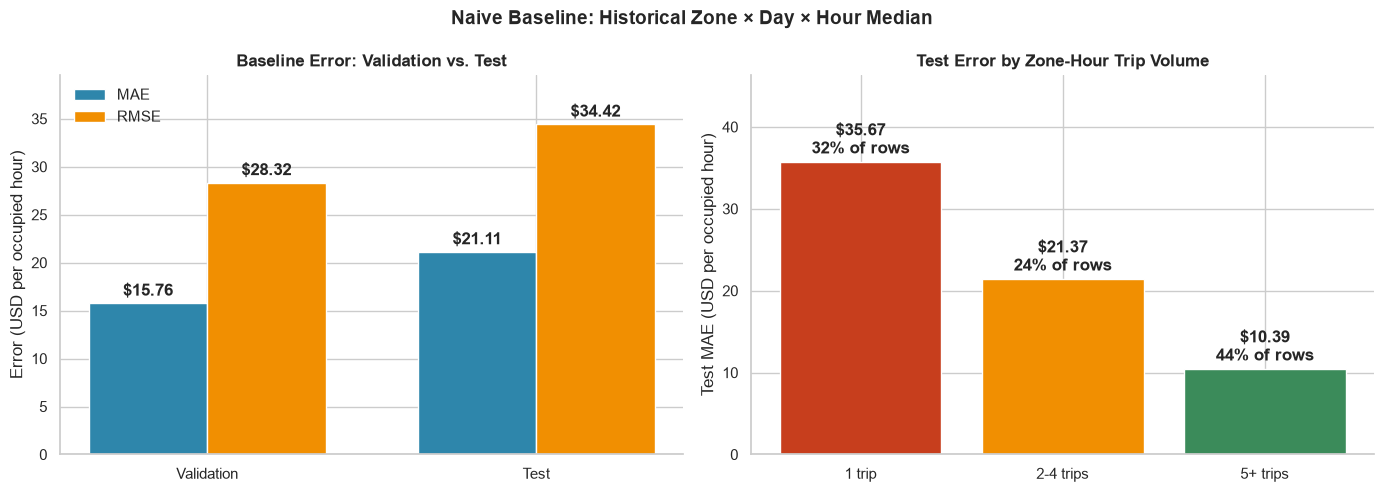

In [17]:
metric_colors = {"MAE": "#2E86AB", "RMSE": "#F18F01"}
volume_colors = ["#C73E1D", "#F18F01", "#3B8B5A"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos = np.arange(len(baseline_results))
bar_width = 0.36
for offset, metric in [(-bar_width / 2, "MAE"), (bar_width / 2, "RMSE")]:
    values = baseline_results[f"{metric} (USD/hr)"]
    bars = axes[0].bar(x_pos + offset, values, bar_width, label=metric, color=metric_colors[metric])
    axes[0].bar_label(bars, labels=[f"${v:.2f}" for v in values], padding=3, fontweight="bold")
axes[0].set_xticks(x_pos, baseline_results.index)
axes[0].set_ylabel("Error (USD per occupied hour)")
axes[0].set_ylim(0, baseline_results["RMSE (USD/hr)"].max() * 1.15)
axes[0].set_title("Baseline Error: Validation vs. Test", fontweight="bold")
axes[0].legend(frameon=False)

test_volume = volume_summary[volume_summary["split"] == "Test"]
bars = axes[1].bar(test_volume["trip_volume"].astype(str), test_volume["mae_usd_per_hr"], color=volume_colors)
axes[1].bar_label(
    bars,
    labels=[f"${m:.2f}\n{s:.0%} of rows" for m, s in zip(test_volume["mae_usd_per_hr"], test_volume["share_of_rows"])],
    padding=3,
    fontweight="bold",
)
axes[1].set_ylabel("Test MAE (USD per occupied hour)")
axes[1].set_ylim(0, test_volume["mae_usd_per_hr"].max() * 1.3)
axes[1].set_title("Test Error by Zone-Hour Trip Volume", fontweight="bold")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Naive Baseline: Historical Zone × Day × Hour Median", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

#### 6.0.3 Baseline Interpretation

- **This is the bar to beat.** On the held-out test period (Oct 12 to Nov 30, 2025), looking up the historical median for each zone, day and hour misses by **$21.11 per occupied hour on average** (RMSE $34.42, R² 0.14). A model is only worth deploying if it does meaningfully better.
- **Test error is higher than validation error because the test months are harder.** The baseline never learns from the validation data, yet its MAE still rises from $15.76 to $21.11 between the two periods. This period shift, not overfitting, is why every model in Section 6 shows a similar validation-to-test jump.
- **Most of the error comes from single-trip zone-hours.** They make up 32% of test rows but 54% of the total test error (MAE $35.67, versus $10.39 for zone-hours with 5+ trips). One short, high-fare trip can swing that hour's $/hr, so part of the remaining error is noise no model can predict.
- **Coverage is near complete.** 98.9% of test rows had a matching zone × day × hour history from training; the rest used the zone-level or overall median.

### 6.1 Model 1: XGBoost Regressor (Champion)

**Model/Method Name:** XGBoost Regressor (`xgboost.XGBRegressor`, gradient-boosted decision trees, `reg:absoluteerror` objective, native categorical support)

*Academic References:*

* Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. In *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining* (pp. 785–794). https://doi.org/10.1145/2939672.2939785
* Kankanamge, K. D., Witharanage, Y. R., Withanage, C. S., Hansini, M., Lakmal, D., & Thayasivam, U. (2019). Taxi trip travel time prediction with isolated XGBoost regression. In *2019 Moratuwa Engineering Research Conference (MERCon)* (pp. 54–59). IEEE. https://doi.org/10.1109/MERCon.2019.8818915
* Moorthy, P. (2025). Robust taxi fare prediction under noisy conditions: A comparative study of GAT, TimesNet, and XGBoost [Preprint]. arXiv. https://doi.org/10.48550/arXiv.2507.20008

*Documentation Link:* https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBRegressor

*Purpose:* Tree-based gradient boosting model suited to nonlinear tabular data. It can learn complex interactions among zone, time, congestion, fee exposure and demand without manually specifying every interaction term, which is useful when revenue changes are not linear and congestion has tipping-point behavior. Kankanamge et al. (2019) used XGBoost on large-scale taxi data and compared it with SVR and a Neural Network; this study adapts that comparative structure to net revenue per occupied driving hour.

#### 6.1.1 Baseline XGBoost Model

In [18]:
print("Training baseline XGBoost model...")

xgb_baseline = xgb.XGBRegressor(
    objective='reg:absoluteerror',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    enable_categorical=True,
    random_state=42,
    n_jobs=-1
)

xgb_baseline.fit(
    X_train_xgb,
    y_train
)

print("Baseline XGBoost training complete.")

Training baseline XGBoost model...


Baseline XGBoost training complete.


#### 6.1.2 Baseline Validation Performance

In [19]:
xgb_val_pred = xgb_baseline.predict(X_val_xgb)

xgb_val_mae = mean_absolute_error(
    y_val,
    xgb_val_pred
)

xgb_val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        xgb_val_pred
    )
)

xgb_val_r2 = r2_score(
    y_val,
    xgb_val_pred
)

xgb_val_spearman, xgb_val_spearman_p = spearmanr(
    y_val,
    xgb_val_pred
)

print("----- BASELINE XGBOOST: VALIDATION PERFORMANCE -----")
print(f"MAE:      ${xgb_val_mae:.2f}/hr")
print(f"RMSE:     ${xgb_val_rmse:.2f}/hr")
print(f"R²:        {xgb_val_r2:.4f}")
print(f"Spearman:  {xgb_val_spearman:.4f}")

----- BASELINE XGBOOST: VALIDATION PERFORMANCE -----
MAE:      $14.63/hr
RMSE:     $27.00/hr
R²:        0.2282
Spearman:  0.5888


,actual,predicted,absolute_error
0,106.680628,91.249222,15.431406
1,9.175844,99.440269,90.264426
2,44.087387,61.518547,17.431160
3,9.339938,81.267845,71.927907
4,117.383886,86.322395,31.061491
5,22.115308,96.717392,74.602084
6,97.099325,98.722549,1.623224
7,105.185787,99.906052,5.279735
8,45.678832,94.848129,49.169297
9,66.210153,94.106575,27.896422


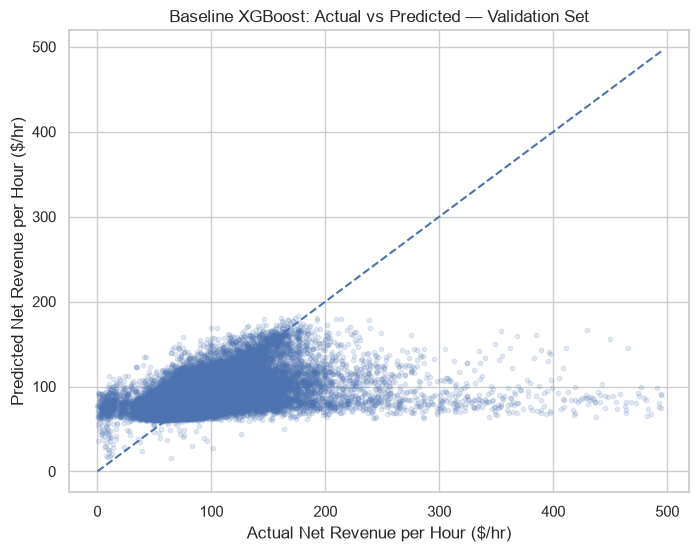

In [20]:
validation_results = pd.DataFrame({
    'actual': y_val.values,
    'predicted': xgb_val_pred
})

validation_results['absolute_error'] = (
    validation_results['actual']
    - validation_results['predicted']
).abs()

display(validation_results.head(10))

plt.figure(figsize=(8, 6))

plt.scatter(
    y_val,
    xgb_val_pred,
    alpha=0.15,
    s=10
)

min_val = min(
    y_val.min(),
    xgb_val_pred.min()
)

max_val = max(
    y_val.max(),
    xgb_val_pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel('Actual Net Revenue per Hour ($/hr)')
plt.ylabel('Predicted Net Revenue per Hour ($/hr)')
plt.title('Baseline XGBoost: Actual vs Predicted — Validation Set')

plt.show()

#### 6.1.3 XGBoost Hyperparameter Tuning

Hyperparameters are tuned using the chronological validation set only.  
The held-out test set remains untouched during model development.

The primary tuning criterion is validation MAE, with RMSE, R², and
Spearman rank correlation retained as supporting metrics.

In [21]:
print("Starting XGBoost hyperparameter tuning...")

param_distributions = {
    'max_depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.02, 0.03, 0.05, 0.08],
    'min_child_weight': [1, 3, 5, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 0.5],
    'reg_lambda': [1, 2, 5, 10]
}

# Keep the search manageable because the training set is large
parameter_samples = list(
    ParameterSampler(
        param_distributions,
        n_iter=15,
        random_state=42
    )
)

tuning_results = []

tuning_start = time.time()

for i, params in enumerate(parameter_samples, start=1):

    print(f"\nModel {i}/{len(parameter_samples)}")
    print(params)

    model = xgb.XGBRegressor(
        objective='reg:absoluteerror',

        # Large ceiling because early stopping will determine
        # how many boosting rounds are actually needed
        n_estimators=1000,

        tree_method='hist',
        enable_categorical=True,

        early_stopping_rounds=40,
        eval_metric='mae',

        random_state=42,
        n_jobs=-1,

        **params
    )

    model_start = time.time()

    model.fit(
        X_train_xgb,
        y_train,
        eval_set=[(X_val_xgb, y_val)],
        verbose=False
    )

    val_pred = model.predict(X_val_xgb)

    mae = mean_absolute_error(
        y_val,
        val_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            val_pred
        )
    )

    r2 = r2_score(
        y_val,
        val_pred
    )

    spearman, _ = spearmanr(
        y_val,
        val_pred
    )

    model_runtime = time.time() - model_start

    tuning_results.append({
        **params,

        'best_iteration': model.best_iteration,

        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Spearman': spearman,

        'runtime_sec': model_runtime
    })

    print(
        f"MAE=${mae:.2f} | "
        f"RMSE=${rmse:.2f} | "
        f"R²={r2:.4f} | "
        f"Spearman={spearman:.4f} | "
        f"Best iteration={model.best_iteration}"
    )

total_tuning_runtime = time.time() - tuning_start

print(
    f"\nTotal tuning runtime: "
    f"{total_tuning_runtime / 60:.2f} minutes"
)

Starting XGBoost hyperparameter tuning...

Model 1/15
{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0.5, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.02, 'colsample_bytree': 1.0}


MAE=$14.66 | RMSE=$26.99 | R²=0.2288 | Spearman=0.5878 | Best iteration=998

Model 2/15
{'subsample': 0.7, 'reg_lambda': 10, 'reg_alpha': 0.01, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.02, 'colsample_bytree': 0.7}


MAE=$14.61 | RMSE=$26.98 | R²=0.2293 | Spearman=0.5897 | Best iteration=704

Model 3/15
{'subsample': 0.9, 'reg_lambda': 10, 'reg_alpha': 0, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.02, 'colsample_bytree': 0.8}


MAE=$14.66 | RMSE=$27.02 | R²=0.2270 | Spearman=0.5876 | Best iteration=999

Model 4/15
{'subsample': 0.7, 'reg_lambda': 10, 'reg_alpha': 0.5, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.9}


MAE=$14.66 | RMSE=$27.02 | R²=0.2271 | Spearman=0.5875 | Best iteration=995

Model 5/15
{'subsample': 0.7, 'reg_lambda': 2, 'reg_alpha': 0.01, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.02, 'colsample_bytree': 0.9}


...

MAE=$14.64 | RMSE=$26.97 | R²=0.2299 | Spearman=0.5888 | Best iteration=768

Model 12/15
{'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


MAE=$14.62 | RMSE=$26.98 | R²=0.2294 | Spearman=0.5887 | Best iteration=505

Model 13/15
{'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.01, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


MAE=$14.64 | RMSE=$27.02 | R²=0.2272 | Spearman=0.5877 | Best iteration=795

Model 14/15
{'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.02, 'colsample_bytree': 0.7}


MAE=$14.60 | RMSE=$26.98 | R²=0.2294 | Spearman=0.5895 | Best iteration=640

Model 15/15
{'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


MAE=$14.59 | RMSE=$26.96 | R²=0.2306 | Spearman=0.5897 | Best iteration=419

Total tuning runtime: 16.92 minutes


In [22]:
tuning_df = pd.DataFrame(tuning_results)

# Primary criterion = lowest MAE
tuning_df = tuning_df.sort_values(
    by='MAE',
    ascending=True
).reset_index(drop=True)

print("----- TOP XGBOOST CONFIGURATIONS -----")

display(
    tuning_df[
        [
            'MAE',
            'RMSE',
            'R2',
            'Spearman',
            'best_iteration',
            'max_depth',
            'learning_rate',
            'min_child_weight',
            'subsample',
            'colsample_bytree',
            'reg_alpha',
            'reg_lambda',
            'runtime_sec'
        ]
    ].head(10)
)

----- TOP XGBOOST CONFIGURATIONS -----


,MAE,RMSE,R2,Spearman,best_iteration,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda,runtime_sec
0,14.594368,26.958864,0.230639,0.589723,419,8,0.03,5,0.8,0.7,0.00,1,46.986508
1,14.597335,26.952091,0.231025,0.590062,513,8,0.02,3,0.8,0.8,0.50,5,54.362591
2,14.601045,26.943453,0.231518,0.590032,511,8,0.02,3,1.0,0.9,0.10,1,60.958418
3,14.602385,26.980293,0.229415,0.589526,640,7,0.02,1,0.8,0.7,0.00,1,68.222245
4,14.607474,26.972582,0.229856,0.589641,496,8,0.02,1,0.7,0.9,0.01,2,48.331159
5,14.608089,26.982733,0.229276,0.589657,704,7,0.02,3,0.7,0.7,0.01,10,59.991655
6,14.620568,26.972915,0.229837,0.588491,340,6,0.08,3,0.9,0.7,0.00,5,43.781624
7,14.621584,26.980259,0.229417,0.588736,505,6,0.05,5,0.9,0.8,0.00,1,62.692218
8,14.639526,26.970979,0.229947,0.588758,768,6,0.02,5,1.0,1.0,0.01,2,88.755239
9,14.642232,27.018215,0.227248,0.587689,795,5,0.03,5,0.8,0.7,0.01,2,78.072124


In [23]:
best_tuned_mae = tuning_df.loc[0, 'MAE']

mae_improvement = (
    xgb_val_mae - best_tuned_mae
)

mae_improvement_pct = (
    mae_improvement / xgb_val_mae
) * 100

print("----- BASELINE vs BEST TUNED XGBOOST -----")

print(
    f"Baseline MAE:   ${xgb_val_mae:.2f}/hr"
)

print(
    f"Best Tuned MAE: ${best_tuned_mae:.2f}/hr"
)

print(
    f"MAE Improvement: "
    f"${mae_improvement:.2f}/hr "
    f"({mae_improvement_pct:.2f}%)"
)

----- BASELINE vs BEST TUNED XGBOOST -----
Baseline MAE:   $14.63/hr
Best Tuned MAE: $14.59/hr
MAE Improvement: $0.03/hr (0.22%)


**Tuning Result.** Hyperparameter tuning produced a modest improvement over the
baseline XGBoost model. Validation MAE decreased from $14.63/hr to $14.59/hr
(0.22% improvement), while RMSE decreased from $27.00/hr to $26.96/hr.
R² increased from 0.2282 to 0.2306, and Spearman rank correlation increased
from 0.5888 to 0.5897.

The limited improvement suggests that the baseline configuration was already
reasonably close to the best-performing parameter region for the current
feature set. The best validation configuration was retained for final XGBoost
training.

#### 6.1.4 Final XGBoost Model and Held-Out Test Evaluation

In [24]:
print("Preparing final XGBoost model...")

best_params = tuning_df.iloc[0]

print("Selected validation configuration:")
print(f"max_depth:        {int(best_params['max_depth'])}")
print(f"learning_rate:    {best_params['learning_rate']}")
print(f"min_child_weight: {best_params['min_child_weight']}")
print(f"subsample:        {best_params['subsample']}")
print(f"colsample_bytree: {best_params['colsample_bytree']}")
print(f"reg_alpha:        {best_params['reg_alpha']}")
print(f"reg_lambda:       {best_params['reg_lambda']}")
print(f"best_iteration:   {int(best_params['best_iteration'])}")

# XGBoost best_iteration is zero-based,
# so add 1 for the final number of trees.
final_n_estimators = int(best_params['best_iteration']) + 1

Preparing final XGBoost model...
Selected validation configuration:
max_depth:        8
learning_rate:    0.03
min_child_weight: 5.0
subsample:        0.8
colsample_bytree: 0.7
reg_alpha:        0.0
reg_lambda:       1.0
best_iteration:   419


In [25]:
X_dev = pd.concat(
    [X_train, X_val],
    axis=0
).reset_index(drop=True)

y_dev = pd.concat(
    [y_train, y_val],
    axis=0
).reset_index(drop=True)

print(f"Development rows: {len(X_dev):,}")
print(f"Test rows:        {len(X_test):,}")

Development rows: 468,057
Test rows:        77,328


In [26]:
final_location_dtype = CategoricalDtype(
    categories=np.sort(
        X_dev['PULocationID'].unique()
    ),
    ordered=False
)

final_day_dtype = CategoricalDtype(
    categories=[
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ],
    ordered=False
)

X_dev_xgb = X_dev.copy()
X_test_final_xgb = X_test.copy()

for split_df in [
    X_dev_xgb,
    X_test_final_xgb
]:
    split_df['PULocationID'] = (
        split_df['PULocationID']
        .astype(final_location_dtype)
    )

    split_df['day_of_week'] = (
        split_df['day_of_week']
        .astype(final_day_dtype)
    )

In [27]:
print("\nTraining final XGBoost on Train + Validation...")

final_xgb = xgb.XGBRegressor(
    objective='reg:absoluteerror',

    n_estimators=final_n_estimators,
    max_depth=int(best_params['max_depth']),
    learning_rate=float(best_params['learning_rate']),
    min_child_weight=float(best_params['min_child_weight']),
    subsample=float(best_params['subsample']),
    colsample_bytree=float(best_params['colsample_bytree']),
    reg_alpha=float(best_params['reg_alpha']),
    reg_lambda=float(best_params['reg_lambda']),

    tree_method='hist',
    enable_categorical=True,

    random_state=42,
    n_jobs=-1
)

final_xgb.fit(
    X_dev_xgb,
    y_dev
)

print("Final XGBoost training complete.")


Training final XGBoost on Train + Validation...


Final XGBoost training complete.


----- FINAL XGBOOST: HELD-OUT TEST PERFORMANCE -----
MAE:      $19.68/hr
RMSE:     $33.02/hr
R²:        0.2127
Spearman:  0.5622

Final XGBoost Results Table:


,Model,MAE,RMSE,R2,Spearman
0,XGBoost,19.68114,33.019488,0.212668,0.562248


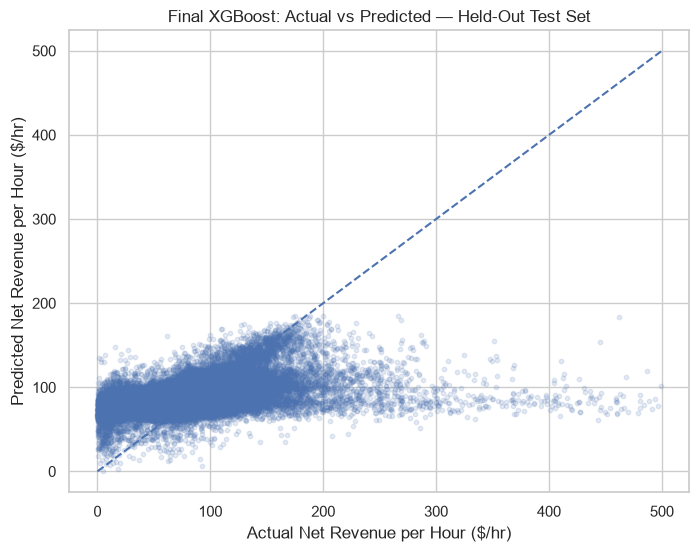

In [28]:
xgb_test_pred = final_xgb.predict(X_test_final_xgb)

xgb_test_mae = mean_absolute_error(
    y_test,
    xgb_test_pred
)

xgb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_test_pred
    )
)

xgb_test_r2 = r2_score(
    y_test,
    xgb_test_pred
)

xgb_test_spearman, xgb_test_spearman_p = spearmanr(
    y_test,
    xgb_test_pred
)

print("----- FINAL XGBOOST: HELD-OUT TEST PERFORMANCE -----")
print(f"MAE:      ${xgb_test_mae:.2f}/hr")
print(f"RMSE:     ${xgb_test_rmse:.2f}/hr")
print(f"R²:        {xgb_test_r2:.4f}")
print(f"Spearman:  {xgb_test_spearman:.4f}")

xgb_final_results = pd.DataFrame({
    'Model': ['XGBoost'],
    'MAE': [xgb_test_mae],
    'RMSE': [xgb_test_rmse],
    'R2': [xgb_test_r2],
    'Spearman': [xgb_test_spearman]
})

model_results["XGBoost (Champion)"] = {
    'MAE (USD/hr)': xgb_test_mae,
    'RMSE (USD/hr)': xgb_test_rmse,
    'R² Score': xgb_test_r2
}

print("\nFinal XGBoost Results Table:")
display(xgb_final_results)

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    xgb_test_pred,
    alpha=0.15,
    s=10
)

min_val = min(
    y_test.min(),
    xgb_test_pred.min()
)

max_val = max(
    y_test.max(),
    xgb_test_pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel('Actual Net Revenue per Hour ($/hr)')
plt.ylabel('Predicted Net Revenue per Hour ($/hr)')
plt.title('Final XGBoost: Actual vs Predicted — Held-Out Test Set')

plt.show()

**Held-Out Test Interpretation.**  
The tuned XGBoost model achieved a test MAE of $19.68/hr and RMSE of
$33.02/hr, with an R² of 0.2127 and Spearman rank correlation of 0.5622.

Performance was weaker on the later held-out test period than on the
validation period, indicating some temporal degradation in predictive
accuracy. However, the positive Spearman correlation indicates that the model
retains useful ability to rank relatively stronger and weaker zone-hour
combinations, which is important for the fleet-deployment decision problem.

The Actual vs. Predicted plot also shows compression toward the middle of the
target distribution, with many very high actual revenue-per-hour observations
being underpredicted.

#### 6.1.5 Feature Importance and Model Interpretation

Feature importance is examined to identify which predictors contribute most
to the final XGBoost model's revenue-per-hour predictions.

XGBoost gain importance measures how much each feature improves the model's
objective when it is used for a tree split. Higher gain indicates greater
predictive contribution.

In [29]:
booster = final_xgb.get_booster()

gain_scores = booster.get_score(
    importance_type='gain'
)

feature_importance = (
    pd.DataFrame(
        gain_scores.items(),
        columns=['Feature', 'Gain']
    )
    .sort_values(
        'Gain',
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance['Gain_Percent'] = (
    feature_importance['Gain']
    / feature_importance['Gain'].sum()
) * 100

print("----- XGBOOST FEATURE IMPORTANCE -----")

display(feature_importance)

----- XGBOOST FEATURE IMPORTANCE -----


,Feature,Gain,Gain_Percent
0,pickup_hour,78.377808,23.739787
1,PULocationID,62.612759,18.964725
2,avg_speed_mph_lag1h,45.296803,13.719910
3,is_weekend,43.299778,13.115033
4,day_of_week,28.462225,8.620899
5,avg_speed_mph_lag24h,26.042057,7.887856
6,trip_count_lag1h,15.203953,4.605112
7,trip_count_lag24h,12.739636,3.858698
8,avg_fee_impact_pct_lag1h,9.911108,3.001967
9,avg_fee_impact_pct_lag24h,8.207669,2.486014


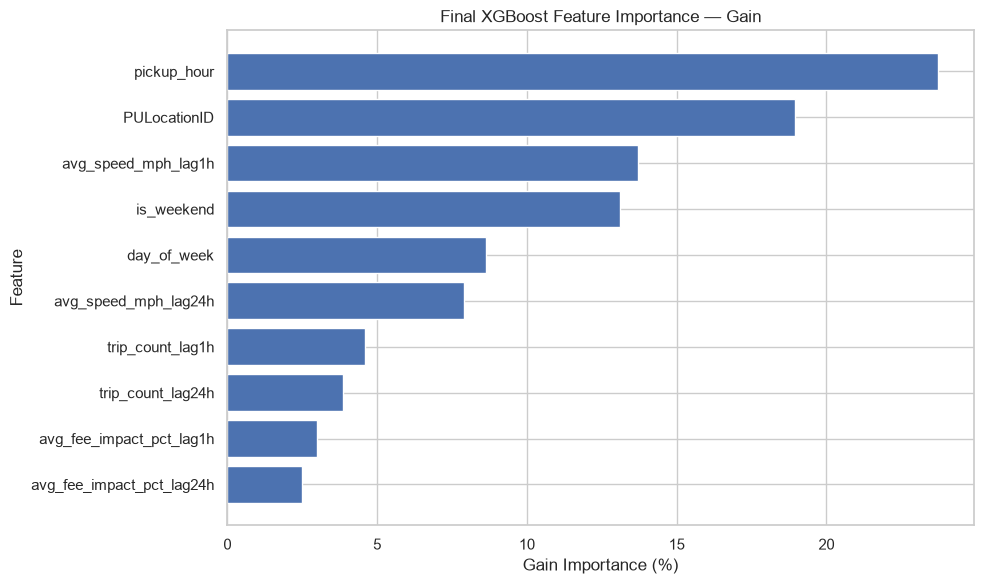

In [30]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'][::-1],
    feature_importance['Gain_Percent'][::-1]
)

plt.xlabel('Gain Importance (%)')
plt.ylabel('Feature')
plt.title('Final XGBoost Feature Importance — Gain')

plt.tight_layout()
plt.show()

In [31]:
xgb_test_results = test[
    [
        'PULocationID',
        'pickup_date',
        'pickup_hour',
        'day_of_week',
        'is_weekend',
        'net_revenue_per_hour'
    ]
].copy()

xgb_test_results['predicted_net_revenue_per_hour'] = (
    xgb_test_pred
)

xgb_test_results['absolute_error'] = (
    xgb_test_results['net_revenue_per_hour']
    - xgb_test_results['predicted_net_revenue_per_hour']
).abs()

print(
    f"Stored {len(xgb_test_results):,} held-out "
    f"XGBoost predictions for later analysis."
)

display(xgb_test_results.head(10))

Stored 77,328 held-out XGBoost predictions for later analysis.


,PULocationID,pickup_date,pickup_hour,day_of_week,is_weekend,net_revenue_per_hour,predicted_net_revenue_per_hour,absolute_error
468057,4,2025-10-12 01:00:00,1,Sunday,1,86.107757,91.622704,5.514947
468058,7,2025-10-12 01:00:00,1,Sunday,1,66.787522,85.790077,19.002555
468059,13,2025-10-12 01:00:00,1,Sunday,1,110.590476,97.846977,12.743499
468060,17,2025-10-12 01:00:00,1,Sunday,1,58.238908,80.110992,21.872085
468061,25,2025-10-12 01:00:00,1,Sunday,1,70.704526,82.357895,11.653369
468062,36,2025-10-12 01:00:00,1,Sunday,1,83.534328,80.684120,2.850208
468063,41,2025-10-12 01:00:00,1,Sunday,1,108.303030,86.771957,21.531073
468064,42,2025-10-12 01:00:00,1,Sunday,1,100.928949,86.266029,14.662920
468065,43,2025-10-12 01:00:00,1,Sunday,1,109.666667,98.484749,11.181918
468066,48,2025-10-12 01:00:00,1,Sunday,1,87.748513,97.697586,9.949073


##### SHAP-Style Feature Contribution Analysis

To complement XGBoost gain importance, SHAP-style contribution values are
used to estimate how strongly each predictor contributes to individual model
predictions.

The analysis is performed on a reproducible sample of the held-out test set
to reduce computational cost. Mean absolute SHAP contribution is used as a
global measure of feature influence.

----- XGBOOST SHAP-STYLE GLOBAL IMPORTANCE -----


,Feature,Mean_Abs_SHAP
0,PULocationID,6.250924
1,pickup_hour,5.095974
2,avg_speed_mph_lag1h,1.919243
3,day_of_week,1.345001
4,avg_speed_mph_lag24h,0.999791
5,avg_fee_impact_pct_lag1h,0.586873
6,trip_count_lag1h,0.375255
7,avg_fee_impact_pct_lag24h,0.326404
8,is_weekend,0.311970
9,trip_count_lag24h,0.275393


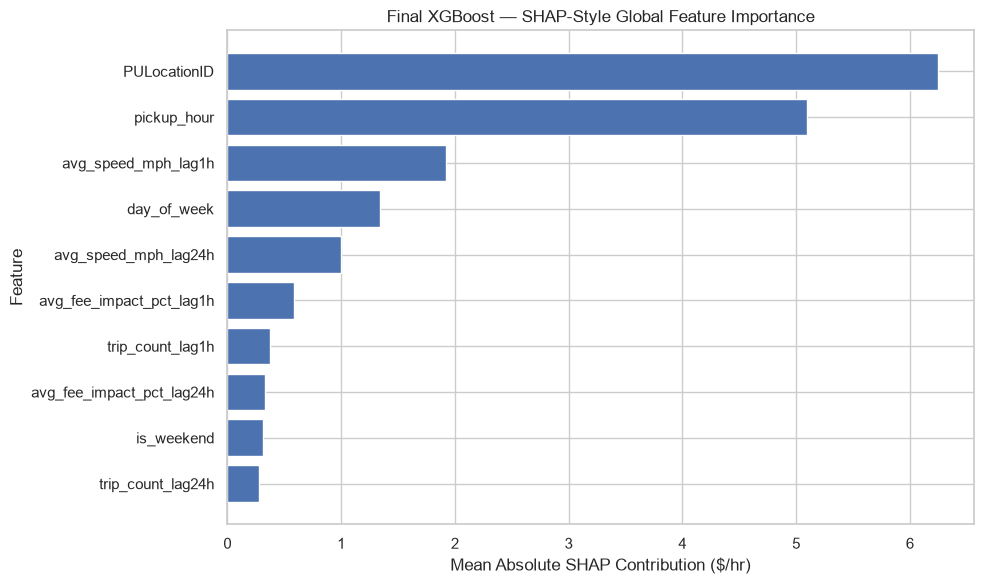

In [32]:
sample_n = min(10_000, len(X_test_final_xgb))

X_shap = X_test_final_xgb.sample(
    n=sample_n,
    random_state=42
)

shap_matrix = xgb.DMatrix(
    X_shap,
    enable_categorical=True
)

# Native XGBoost SHAP-style contribution values
shap_values = (
    final_xgb
    .get_booster()
    .predict(
        shap_matrix,
        pred_contribs=True
    )
)

# Final column is the bias/base value, so exclude it
shap_feature_values = shap_values[:, :-1]

shap_df = pd.DataFrame(
    shap_feature_values,
    columns=X_shap.columns,
    index=X_shap.index
)

shap_importance = pd.DataFrame({
    'Feature': X_shap.columns,
    'Mean_Abs_SHAP': shap_df.abs().mean().values
})

shap_importance = (
    shap_importance
    .sort_values(
        'Mean_Abs_SHAP',
        ascending=False
    )
    .reset_index(drop=True)
)

print("----- XGBOOST SHAP-STYLE GLOBAL IMPORTANCE -----")

display(shap_importance)

plt.figure(figsize=(10, 6))

plt.barh(
    shap_importance['Feature'][::-1],
    shap_importance['Mean_Abs_SHAP'][::-1]
)

plt.xlabel('Mean Absolute SHAP Contribution ($/hr)')
plt.ylabel('Feature')
plt.title('Final XGBoost — SHAP-Style Global Feature Importance')

plt.tight_layout()
plt.show()

Mean absolute SHAP contribution represents the average magnitude by which a
feature shifts the model's predicted net revenue per occupied hour away from
its baseline prediction. Larger values indicate stronger influence on model
predictions.

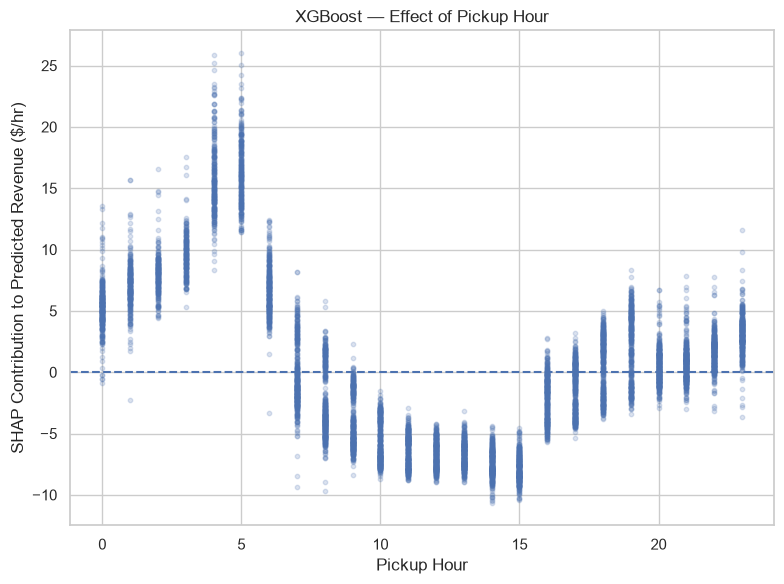

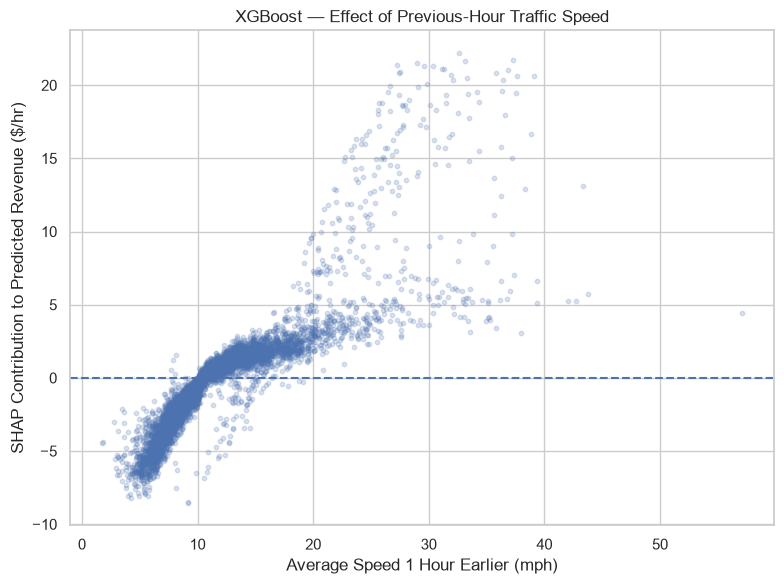

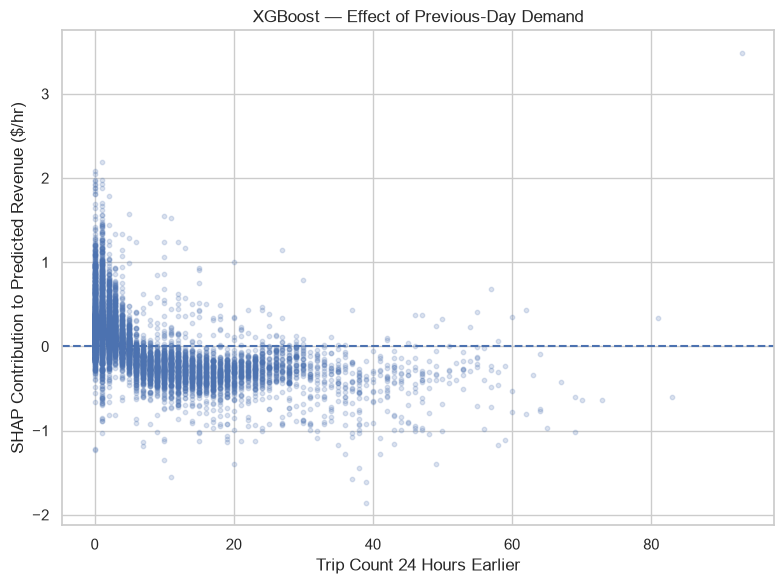

In [33]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_shap['pickup_hour'],
    shap_df['pickup_hour'],
    alpha=0.2,
    s=10
)

plt.axhline(
    0,
    linestyle='--'
)

plt.xlabel('Pickup Hour')
plt.ylabel('SHAP Contribution to Predicted Revenue ($/hr)')
plt.title('XGBoost — Effect of Pickup Hour')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))

plt.scatter(
    X_shap['avg_speed_mph_lag1h'],
    shap_df['avg_speed_mph_lag1h'],
    alpha=0.2,
    s=10
)

plt.axhline(
    0,
    linestyle='--'
)

plt.xlabel('Average Speed 1 Hour Earlier (mph)')
plt.ylabel('SHAP Contribution to Predicted Revenue ($/hr)')
plt.title('XGBoost — Effect of Previous-Hour Traffic Speed')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))

plt.scatter(
    X_shap['trip_count_lag24h'],
    shap_df['trip_count_lag24h'],
    alpha=0.2,
    s=10
)

plt.axhline(
    0,
    linestyle='--'
)

plt.xlabel('Trip Count 24 Hours Earlier')
plt.ylabel('SHAP Contribution to Predicted Revenue ($/hr)')
plt.title('XGBoost — Effect of Previous-Day Demand')

plt.tight_layout()
plt.show()

### XGBoost Model Interpretation

The final XGBoost model indicates that temporal, spatial, and traffic-related
conditions are the strongest contributors to predicted net revenue per occupied
driving hour.

**Pickup Hour.**  
Pickup hour was the most influential feature according to XGBoost gain
importance. The SHAP-style contribution plot shows strong time-of-day effects.
Early-morning hours, particularly around 4:00–5:00 AM, generally contribute
positively to predicted revenue efficiency. The contribution declines after
approximately 6:00 AM and becomes predominantly negative during the late
morning and afternoon, with the strongest negative effects occurring around
12:00–3:00 PM. Contributions begin recovering during the late afternoon and
evening. This suggests that the expected revenue efficiency of a pickup zone is
highly dependent on the hour in which drivers are deployed.

**Pickup Location.**  
`PULocationID` was the second most important feature based on gain importance,
indicating substantial spatial differences in expected net revenue per occupied
hour. Because location IDs are categorical identifiers rather than ordered
numeric quantities, their effects should be examined through zone-level
predictions rather than by interpreting the numeric ID itself.

**Previous-Hour Traffic Speed.**  
Historical traffic speed also had a substantial influence on predictions. Very
low previous-hour speeds generally produced negative SHAP contributions, while
higher speeds increasingly produced positive contributions. The contribution
appears to transition from predominantly negative to positive at approximately
10–12 mph. This pattern suggests that the model associates relatively freer
traffic conditions with greater revenue efficiency, while slower traffic tends
to reduce predicted net revenue per occupied driving hour.

**Previous-Day Demand.**  
Previous-day trip demand had a smaller effect on model predictions. At low
values, its contribution varies around zero, while higher previous-day trip
counts generally produce small negative contributions. Therefore, greater
historical demand does not necessarily correspond to greater revenue efficiency
per occupied hour. Demand may interact with pickup location, time of day, and
traffic conditions, and should therefore not be used alone as a deployment
criterion.

Overall, the model suggests that driver deployment decisions should consider
the combination of pickup hour, pickup zone, and recent traffic conditions
rather than relying solely on historical trip volume. These feature
contributions describe patterns learned by the predictive model and should not
be interpreted as causal effects.

### 6.2 Model 2: Support Vector Regressor - SVR (Challenger 1)

**Model/Method Name:** Support Vector Regression (`sklearn.svm.SVR`, RBF kernel)

*Academic References:*

* Wu, C.-H., Wei, C.-C., Su, D.-C., Chang, M.-H., & Ho, J.-M. (2003). Travel time prediction with support vector regression. In *Proceedings of the 2003 IEEE International Conference on Intelligent Transportation Systems*. IEEE.
* Kankanamge, K. D., et al. (2019). Taxi trip travel time prediction with isolated XGBoost regression. In *2019 Moratuwa Engineering Research Conference (MERCon)* (pp. 54–59). IEEE. https://doi.org/10.1109/MERCon.2019.8818915 (The paper uses Wu et al.'s SVR model, tuned on a sample of 20,000 in-lier trips, as a benchmark.)

*Documentation Link:* https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html

*Purpose:* SVR is a non-parametric regression technique that fits a function within an $\epsilon$-margin of tolerance in a high-dimensional feature space. With a Radial Basis Function (RBF) kernel it captures non-linear spatial and time-varying patterns, testing whether a margin-based nonlinear model can predict hourly net revenue as accurately as or better than XGBoost. Kernel SVR fit time grows faster than quadratically with the number of rows (between $O(n^2)$ and $O(n^3)$), so it is trained on a 25,000-row subsample of the training period. It uses the scaled, imputed and one-hot encoded matrices from Section 5 (Pipeline B).

In [34]:
sample_size = min(25000, len(X_train))
X_train_svr = X_train.sample(n=sample_size, random_state=42)
y_train_svr = y_train.loc[X_train_svr.index]

X_train_svr_scaled = preprocessor.transform(X_train_svr)

print(f"SVR training subsample: {X_train_svr_scaled.shape[0]:,} rows x {X_train_svr_scaled.shape[1]} columns")

SVR training subsample: 25,000 rows x 271 columns


In [35]:
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1, cache_size=1000)

In [36]:
print(f"\nTraining Base SVR on {len(X_train_svr):,} rows...")
svr_model.fit(X_train_svr_scaled, y_train_svr)

print("Evaluating Base SVR on the validation set...")
y_pred_base = svr_model.predict(X_val_scaled)

mae_base = mean_absolute_error(y_val, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_val, y_pred_base))
r2_base = r2_score(y_val, y_pred_base)

print(f"Base MAE:  ${mae_base:.2f}/hr")
print(f"Base RMSE: ${rmse_base:.2f}/hr")
print(f"Base R²:   {r2_base:.4f}")


Training Base SVR on 25,000 rows...


Evaluating Base SVR on the validation set...


Base MAE:  $15.94/hr
Base RMSE: $28.76/hr
Base R²:   0.1245


In [37]:
print(f"\nStarting Hyperparameter Tuning on {len(X_train_svr):,} rows...")

param_distributions = {
    'C': [0.1, 1.0, 10.0, 50.0],
    'epsilon': [0.01, 0.05, 0.1, 0.5],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

random_search = RandomizedSearchCV(
    estimator=svr_model,
    param_distributions=param_distributions,
    n_iter=10,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train_svr_scaled, y_train_svr)

print("\nBest Parameters Found:")
print(random_search.best_params_)

best_svr_model = random_search.best_estimator_


Starting Hyperparameter Tuning on 25,000 rows...
Fitting 3 folds for each of 10 candidates, totalling 30 fits



Best Parameters Found:
{'gamma': 'scale', 'epsilon': 0.5, 'C': 10.0}


In [38]:
print("\nEvaluating Tuned SVR on the validation and test sets...")
y_pred_tuned = evaluate_and_log("SVR (Challenger 1)", best_svr_model, X_val_scaled, y_val, dataset_label="Validation")
svr_preds = evaluate_and_log("SVR (Challenger 1)", best_svr_model, X_test_scaled, y_test, dataset_label="Test")

mae_tuned = mean_absolute_error(y_val, y_pred_tuned)

print(f"Validation MAE Improvement: ${mae_base - mae_tuned:.2f}/hr")


Evaluating Tuned SVR on the validation and test sets...


 SVR (Challenger 1) — Validation Set Evaluation
MAE:  USD 15.45/hr
RMSE: USD 28.15/hr
R²:   0.1613



 SVR (Challenger 1) — Test Set Evaluation
MAE:  USD 21.09/hr
RMSE: USD 34.67/hr
R²:   0.1322

Validation MAE Improvement: $0.49/hr


### 6.3 Model 3: Multi-Layer Perceptron Neural Network (Challenger 2)

**Model/Method Name:** Multi-Layer Perceptron Regressor (`sklearn.neural_network.MLPRegressor`, ReLU activation, Adam optimizer, early stopping)

*Academic References:*

* Kankanamge, K. D., et al. (2019). Taxi trip travel time prediction with isolated XGBoost regression. In *2019 Moratuwa Engineering Research Conference (MERCon)* (pp. 54–59). IEEE. https://doi.org/10.1109/MERCon.2019.8818915 (compares XGBoost against SVR and a Neural Network using common prediction-error metrics)
* Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). Learning representations by back-propagating errors. *Nature, 323*(6088), 533–536. https://doi.org/10.1038/323533a0

*Documentation Link:* https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html

*Purpose:* Provides flexible nonlinear function approximation and can learn complex relationships among location, time, demand, traffic and fee-related variables. It serves as a distinct learning approach against which XGBoost can be compared. Three architectures are tuned on the chronological validation set using the scaled, imputed and one-hot encoded matrices from Section 5 (Pipeline B).

In [39]:
print("Starting Hyperparameter Tuning for Neural Network (MLPRegressor)...")

nn_param_grid = [
    {'hidden_layer_sizes': (64, 32),      'alpha': 0.0001, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (128, 64),     'alpha': 0.0010, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (64, 32, 16),  'alpha': 0.0010, 'learning_rate_init': 0.001},
]

best_nn_mae = float('inf')
best_nn_params = None
best_nn_model = None
nn_tuning_log = []

for i, params in enumerate(nn_param_grid, 1):
    model = MLPRegressor(
        hidden_layer_sizes=params['hidden_layer_sizes'],
        alpha=params['alpha'],
        learning_rate_init=params['learning_rate_init'],
        activation='relu',
        solver='adam',
        batch_size=256,
        max_iter=150,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42,
        verbose=False
    )
    model.fit(X_train_scaled, y_train)

    val_preds = model.predict(X_val_scaled)
    val_mae = mean_absolute_error(y_val, val_preds)
    val_r2 = r2_score(y_val, val_preds)

    print(f"Trial {i}: {params} | Epochs: {model.n_iter_} --> Val MAE: USD {val_mae:.2f}/hr | Val R²: {val_r2:.4f}")
    nn_tuning_log.append({
        'Architecture': str(params['hidden_layer_sizes']),
        'L2_Alpha': params['alpha'],
        'Learning_Rate': params['learning_rate_init'],
        'Epochs_Run': model.n_iter_,
        'Val_MAE': val_mae,
        'Val_R2': val_r2
    })

    if val_mae < best_nn_mae:
        best_nn_mae = val_mae
        best_nn_params = params
        best_nn_model = model

nn_model = best_nn_model
print(f"\nBest Neural Network Hyperparameters Selected: {best_nn_params}")
display(pd.DataFrame(nn_tuning_log))

_ = evaluate_and_log("Neural Network (Challenger 2)", nn_model, X_val_scaled, y_val, dataset_label="Validation")
nn_preds = evaluate_and_log("Neural Network (Challenger 2)", nn_model, X_test_scaled, y_test, dataset_label="Test")

Starting Hyperparameter Tuning for Neural Network (MLPRegressor)...


Trial 1: {'hidden_layer_sizes': (64, 32), 'alpha': 0.0001, 'learning_rate_init': 0.001} | Epochs: 53 --> Val MAE: USD 15.99/hr | Val R²: 0.2273


Trial 2: {'hidden_layer_sizes': (128, 64), 'alpha': 0.001, 'learning_rate_init': 0.001} | Epochs: 29 --> Val MAE: USD 16.34/hr | Val R²: 0.2199


Trial 3: {'hidden_layer_sizes': (64, 32, 16), 'alpha': 0.001, 'learning_rate_init': 0.001} | Epochs: 31 --> Val MAE: USD 15.85/hr | Val R²: 0.2306

Best Neural Network Hyperparameters Selected: {'hidden_layer_sizes': (64, 32, 16), 'alpha': 0.001, 'learning_rate_init': 0.001}


,Architecture,L2_Alpha,Learning_Rate,Epochs_Run,Val_MAE,Val_R2
0,"(64, 32)",0.0001,0.001,53,15.991071,0.227293
1,"(128, 64)",0.0010,0.001,29,16.337730,0.219896
2,"(64, 32, 16)",0.0010,0.001,31,15.854807,0.230633


 Neural Network (Challenger 2) — Validation Set Evaluation
MAE:  USD 15.85/hr
RMSE: USD 26.96/hr
R²:   0.2306



 Neural Network (Challenger 2) — Test Set Evaluation
MAE:  USD 21.29/hr
RMSE: USD 33.75/hr
R²:   0.1773



# 7. Final Side-by-Side Model Comparison

================ FINAL SIDE-BY-SIDE TEST SET COMPARISON ================


,Model,MAE (USD/hr),RMSE (USD/hr),R² Score
0,XGBoost (Champion),$19.68,$33.02,0.2127
1,SVR (Challenger 1),$21.09,$34.67,0.1322
2,Naive Baseline (Historical Median),$21.11,$34.42,0.1442
3,Neural Network (Challenger 2),$21.29,$33.75,0.1773


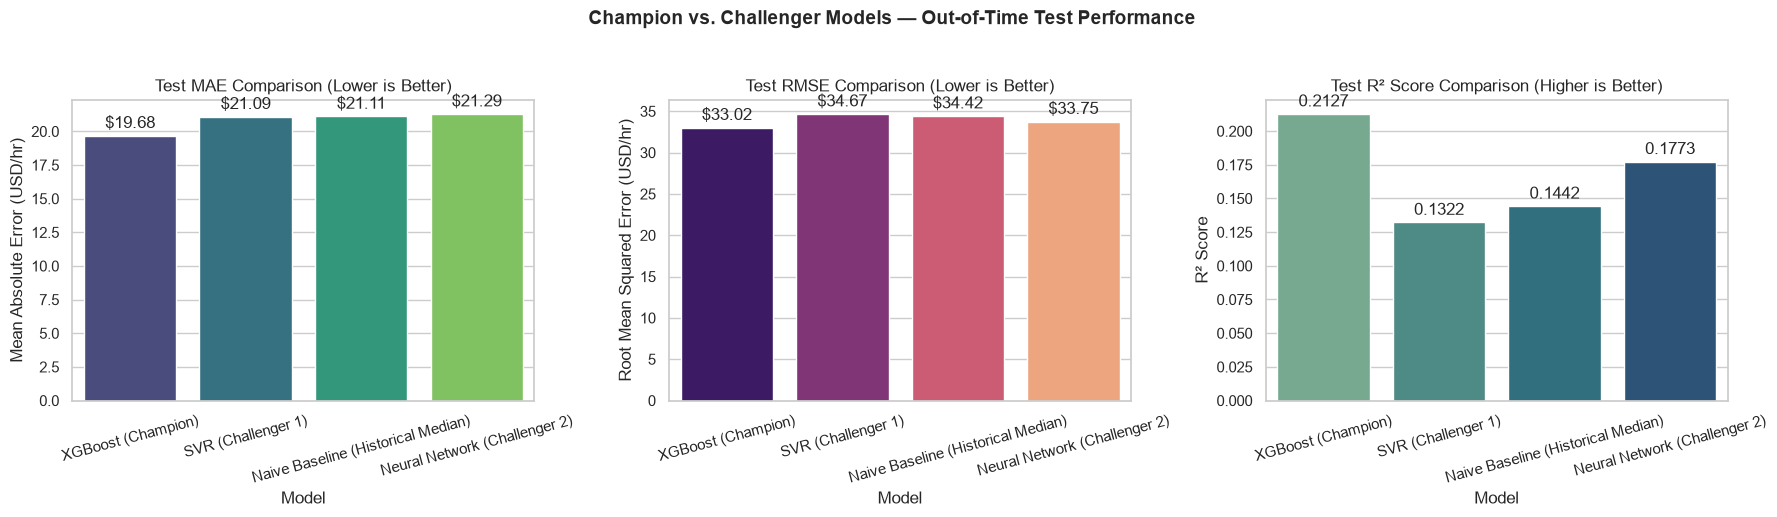

In [40]:
comparison_df = pd.DataFrame(model_results).T.reset_index()

comparison_df.columns = ['Model', 'MAE (USD/hr)', 'RMSE (USD/hr)', 'R² Score']
comparison_df = comparison_df.sort_values(by='MAE (USD/hr)', ascending=True).reset_index(drop=True)
currency = chr(36)

display_df = comparison_df.copy()
display_df['MAE (USD/hr)'] = display_df['MAE (USD/hr)'].apply(lambda x: f"{currency}{x:,.2f}")
display_df['RMSE (USD/hr)'] = display_df['RMSE (USD/hr)'].apply(lambda x: f"{currency}{x:,.2f}")
display_df['R² Score'] = display_df['R² Score'].apply(lambda x: f"{x:.4f}")

print("================ FINAL SIDE-BY-SIDE TEST SET COMPARISON ================")
display(display_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=comparison_df, x='Model', y='MAE (USD/hr)', hue='Model', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Test MAE Comparison (Lower is Better)')
axes[0].set_ylabel('Mean Absolute Error (USD/hr)')
axes[0].tick_params(axis='x', rotation=15)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt=f'{currency}%.2f', padding=3)

sns.barplot(data=comparison_df, x='Model', y='RMSE (USD/hr)', hue='Model', palette='magma', legend=False, ax=axes[1])
axes[1].set_title('Test RMSE Comparison (Lower is Better)')
axes[1].set_ylabel('Root Mean Squared Error (USD/hr)')
axes[1].tick_params(axis='x', rotation=15)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt=f'{currency}%.2f', padding=3)

sns.barplot(data=comparison_df, x='Model', y='R² Score', hue='Model', palette='crest', legend=False, ax=axes[2])
axes[2].set_title('Test R² Score Comparison (Higher is Better)')
axes[2].set_ylabel('R² Score')
axes[2].tick_params(axis='x', rotation=15)
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.4f', padding=3)

plt.suptitle('Champion vs. Challenger Models — Out-of-Time Test Performance', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 7.1 Interpretation

| Model | Validation MAE | Test MAE | Test MAE vs baseline |
|---|---|---|---|
| XGBoost (Champion) | $14.59 | **$19.68** | 6.8% lower |
| SVR (Challenger 1) | $15.45 | $21.09 | 0.1% lower (a tie) |
| Naive Baseline | $15.76 | $21.11 | reference |
| Neural Network (Challenger 2) | $15.85 | $21.29 | 0.9% higher |

- **XGBoost is the final Champion.** Under the PDF's selection rule (lowest test MAE), it wins on every test metric: the lowest MAE ($19.68/hr) and RMSE ($33.02/hr), and the highest R² (0.21). Its Spearman rank correlation of 0.56 means it still ranks stronger and weaker zone-hours in roughly the right order, which is what the deployment table needs.
- **Neither challenger clearly beats the naive baseline on MAE.** SVR ties it ($21.09 vs $21.11) but has a higher RMSE, so it makes more large misses. The Neural Network has a slightly higher MAE than the baseline, yet the second-best RMSE and R² (0.18): it avoids very large misses but is less precise on typical zone-hours.
- **The comparison is not fully equal in training data.** The final XGBoost model is refit on Train + Validation, which includes the seven weeks just before the test period, while SVR and the Neural Network are trained on Train only (SVR on a 25,000-row subsample). The validation column, where every model was trained on Train only, still ranks XGBoost first ($14.59 vs $15.45 and $15.85), so its lead does not come only from the extra data.
- **All models lose about $5–6/hr from validation to test.** The baseline shows the same jump (Section 6.0), so this reflects harder October–November conditions rather than overfitting.

# 8. Key Findings
1. **XGBoost is the final Champion.** It has the lowest test error on every metric: MAE $19.68/hr, RMSE $33.02/hr and R² 0.21, which is 6.8% below the naive baseline's MAE. Its Spearman rank correlation of 0.56 shows it ranks stronger and weaker zone-hours in roughly the right order, which is what a deployment ranking needs.
2. **Neither challenger beats the naive baseline on MAE.** SVR ties it ($21.09 vs $21.11/hr) and the Neural Network is slightly worse ($21.29/hr), although the Neural Network has the second-best RMSE and R², so it makes fewer very large misses.
3. **Time of day and location drive revenue per hour (AQ1).** Pickup zone and pickup hour are the two strongest predictors. Early-morning pickups (around 4–5 AM) raise predicted revenue per occupied hour the most, midday pickups (about 12–3 PM) lower it the most, and the evening recovers to around or above average.
4. **Traffic has a clear tipping point (AQ3).** Previous-hour average speed is the strongest traffic signal. When a zone's average speed in the previous hour falls below about **10 mph**, the model's predicted revenue per hour drops below average, and it keeps falling as traffic slows.
5. **Recent fee exposure adds little to the predictions (AQ2).** The lagged fee-impact features contribute only about 5% of XGBoost's gain importance, so how much the congestion fees cost each fare tier and trip length has to be measured directly with a grouped tier analysis, not through the model.
6. **Demand volume is not the same as revenue efficiency.** Higher trip counts the day before slightly lower the predicted revenue per hour, so busy zones are not automatically the most profitable per occupied hour.
7. **The hardest cases are low-volume zone-hours and the latest months.** Zone-hours with a single trip are 32% of test rows but about 54% of the baseline's test error, and every model's error rises by about $5–6/hr from validation to test because October–November conditions differ from earlier months.

# 9. Recommendations
1. **Adopt XGBoost as the deployment model.** Use its predicted net revenue per occupied hour, averaged to pickup zone × day of week × hour and ranked, as the fleet's deployment table (AQ1).
2. **Shift driver hours toward high-yield time windows.** Prioritize early-morning coverage (about 4–6 AM) and evening hours in the zones the model ranks highest, and reduce idle positioning during the midday low (about 12–3 PM) unless a zone ranks strongly at that time.
3. **Use recent traffic speed as a repositioning trigger (AQ3).** When a zone's average speed over the previous hour falls below about 10 mph, deprioritize it and move drivers toward nearby zones with faster traffic and higher predicted revenue per hour.
4. **Do not deploy by trip volume alone.** Rank zones by predicted revenue per occupied hour rather than by how busy they were, and treat low-volume zone-hours (fewer than about 5 trips) as lower-confidence recommendations.
5. **Quantify the congestion-fee burden directly (AQ2).** Compare `fee_impact_pct` and revenue per hour across fare tiers, trip-length tiers and congestion levels per zone to set minimum-fare and trip-length guidance for drivers.
6. **Retrain regularly.** Because accuracy drops in the latest months, retrain the model on the most recent data (for example, monthly) and monitor its test MAE against the naive baseline before each redeployment.